In [ ]:
# ── Cell 1 ·  Core utilities

import os
import time
import warnings
import random
from argparse import Namespace
from pathlib import Path

# Data & Numerical Computing
import numpy as np
import pandas as pd

# Plotting & Visualization
import matplotlib.pyplot as plt

# JAX Framework
import jax
import jax.numpy as jnp
from jax import random as jax_random
from jax import jit
from functools import partial

print('✓ All required libraries imported and configured.')

# ── Global Configuration & Seeding

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')

# Global JAX random key (used across all cells, including main())
JAX_KEY = None

def seed_everything(seed=42):
    """Set global seed for reproducibility across NumPy, Python random, and JAX."""
    global JAX_KEY
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    JAX_KEY = jax_random.PRNGKey(seed)

# Initialize global seed (this JAX_KEY will be used in main() function)
seed_everything(42)

def rk4_step(q, dynamics_fn, dt):
    """Perform a single RK4 integration step.

    Args:
        q: Current state
        dynamics_fn: Function that computes state derivatives
        dt: Time step

    Returns:
        q_new: Updated state after RK4 step
        deriv: Derivative at current state
    """
    k1 = dynamics_fn(q)
    k2 = dynamics_fn(q + 0.5 * dt * k1)
    k3 = dynamics_fn(q + 0.5 * dt * k2)
    k4 = dynamics_fn(q + dt * k3)

    q_new = q + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
    deriv = dynamics_fn(q)  # Derivative at current state

    return q_new, deriv

# ──  ROSMA Dataset Directory Resolution

# 1. Safely mount Google Drive ONLY if running in Google Colab
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass  # Ignores the error if running on Kaggle or locally

# # 2. Define potential paths using modern pathlib syntax (cleaner than os.path.join)
cwd = Path.cwd()
candidates = [
    Path('/content/drive/MyDrive/ROSMA'), # Google Drive path
    cwd / 'ROSMA',                        # Local/Kaggle fallback
    cwd / 'datasets' / 'ROSMA'            # Alternative local fallback
]

# 3. Find the first valid directory using a clean generator expression
ROSMA_ROOT = next((path for path in candidates if path.is_dir()), None)
if ROSMA_ROOT is None:
    raise FileNotFoundError("Could not find ROSMA_ROOT in any candidate paths.")

print(f'ROSMA_ROOT = {ROSMA_ROOT}')

✓ All required libraries imported and configured.


In [ ]:
# ── Cell 2 · ROSMA data-loading utilities — interaction-only ──────────────

from scipy.spatial.transform import Rotation

DT = 1.0 / 50.0  # 50 Hz
H_DATA_GEN = DT
DVRK_FPS = 50  # dVRK kinematics sampling rate
VIDEO_FPS = 15 # Video recording framerate

def load_usable_times(csv_path=None):
    """
    Returns a hardcoded dictionary replacing the dynamic CSV parser.
    Times are pre-converted to integer seconds.
    Keys strictly match the raw IDs from the CSV.
    """
    return {
        'X01_Wire_Chaser_I_01': [(34, 38, 'R')],
        'X01_Wire_Chaser_I_03': [(30, 35, 'R')],
        'X01_Wire_Chaser_I_04': [(17, 26, 'L')],
        'X01_Wire_Chaser_I_06': [(21, 27, 'L')],
        'X02_Wire_Chaser_I_01': [(33, 41, 'R')],
        'X02_Wire_Chaser_I_02': [(23, 35, 'R')],
        'X02_Wire_Chaser_I_03': [(24, 33, 'R')],
        'X02_Wire_Chaser_I_04': [(17, 24, 'L')],
        'X02_Wire_Chaser_I_05': [(14, 26, 'L')],
        'X02_Wire_Chaser_I_06': [(21, 29, 'L')],
        'X03_Wire_Chaser_I_01': [(19, 35, 'R')],
        'X03_Wire_Chaser_I_03': [(22, 27, 'R')],
        'X03_Wire_Chaser_I_04': [(10, 21, 'L')],
        'X03_Wire_Chaser_I_05': [(7, 12, 'L')],
        'X04_Wire_Chaser_I_01': [(37, 54, 'R')],
        'X04_Wire_Chaser_I_02': [(19, 34, 'R')],
        'X04_Wire_Chaser_I_03': [(20, 33, 'L')],
        'X04_Wire_Chaser_I_04': [(17, 36, 'L')],
        'X04_Wire_Chaser_I_05': [(21, 38, 'L')],
        'X04_Wire_Chaser_I_06': [(43, 55, 'L')],
        'X05_Wire_Chaser_I_01': [(49, 70, 'R')],
        'X05_Wire_Chaser_I_02': [(35, 54, 'R')],
        'X05_Wire_Chaser_I_03': [(26, 43, 'R')],
        'X05_Wire_Chaser_I_04': [(33, 50, 'L')],
        'X05_Wire_Chaser_I_05': [(11, 27, 'L')],
        'X05_Wire_Chaser_I_06': [(24, 37, 'L')],
        'X06_Wire_Chaser_I_01': [(24, 36, 'R')],
        'X06_Wire_Chaser_I_02': [(23, 38, 'R')],
        'X06_Wire_Chaser_I_03': [(7, 24, 'R')],
        'X06_Wire_Chaser_I_04': [(12, 28, 'L')],
        'X06_Wire_Chaser_I_05': [(7, 19, 'L')],
        'X06_Wire_Chaser_I_06': [(12, 20, 'L')],
        'X07_Wire_Chaser_I_01': [(11, 25, 'R')],
        'X07_Wire_Chaser_I_02': [(4, 12, 'R')],
        'X07_Wire_Chaser_I_03': [(9, 17, 'R')],
        'X07_Wire_Chaser_I_04': [(14, 23, 'L')],
        'X07_Wire_Chaser_I_05': [(3, 14, 'L')],
        'X07_Wire_Chaser_I_06': [(4, 23, 'L')],
        'X08_Wire_Chaser_I_01': [(25, 42, 'R')],
        'X08_Wire_Chaser_I_02': [(10, 21, 'R')],
        'X08_Wire_Chaser_I_03': [(11, 25, 'R')],
        'X08_Wire_Chaser_I_04': [(9, 25, 'L')],
        'X08_Wire_Chaser_I_05': [(7, 26, 'L')],
        'X08_Wire_Chaser_I_06': [(8, 20, 'L')],
        'X09_Wire_Chaser_I_02': [(14, 30, 'R')],
        'X09_Wire_Chaser_I_03': [(21, 33, 'R')],
        'X09_Wire_Chaser_I_04': [(18, 28, 'L')],
        'X09_Wire_Chaser_I_05': [(7, 17, 'L')],
        'X09_Wire_Chaser_I_06': [(7, 14, 'L')],
        'X10_Wire_Chaser_I_01': [(20, 24, 'R')],
        'X10_Wire_Chaser_I_02': [(2, 8, 'R')],
        'X10_Wire_Chaser_I_03': [(3, 7, 'R')],
        'X10_Wire_Chaser_I_04': [(11, 14, 'L')],
        'X10_Wire_Chaser_I_05': [(7, 24, 'L')],
        'X11_Wire_Chaser_I_01': [(23, 55, 'R')],
        'X11_Wire_Chaser_I_02': [(45, 54, 'R')],
        'X11_Wire_Chaser_I_03': [(23, 35, 'R')],
        'X11_Wire_Chaser_I_04': [(18, 29, 'L')],
        'X11_Wire_Chaser_I_05': [(3, 11, 'L')],
        'X11_Wire_Chaser_I_06': [(9, 15, 'L')],
        'X12_Wire_Chaser_I_01': [(72, 93, 'R')],
        'X12_Wire_Chaser_I_02': [(13, 25, 'R')],
        'X12_Wire_Chaser_I_03': [(43, 61, 'R')],
        'X12_Wire_Chaser_I_04': [(27, 38, 'L')],
        'X12_Wire_Chaser_I_05': [(7, 23, 'L')],
        'X12_Wire_Chaser_I_06': [(10, 20, 'L')]
    }

def load_sync_map():
    """
    Hardcoded (initial_frame, initial_row) pairs from synchronizationData.txt.
    initial_frame is a VIDEO frame index (15 fps); initial_row is the matching
    CSV row (50 Hz). Both are needed to convert elapsed video-file time -> CSV row.
    """
    return {
        'X01_Wire_Chaser_I_01': (11, 34), 'X01_Wire_Chaser_I_02': (7, 8),  'X01_Wire_Chaser_I_03': (11, 24),
        'X01_Wire_Chaser_I_04': (12, 27), 'X01_Wire_Chaser_I_05': (9, 22), 'X01_Wire_Chaser_I_06': (11, 26),
        'X02_Wire_Chaser_I_01': (9, 7),   'X02_Wire_Chaser_I_02': (24, 20), 'X02_Wire_Chaser_I_03': (24, 50),
        'X02_Wire_Chaser_I_04': (14, 9),  'X02_Wire_Chaser_I_05': (18, 24), 'X02_Wire_Chaser_I_06': (27, 49),
        'X03_Wire_Chaser_I_01': (17, 39), 'X03_Wire_Chaser_I_02': (14, 29), 'X03_Wire_Chaser_I_03': (14, 13),
        'X03_Wire_Chaser_I_04': (23, 41), 'X03_Wire_Chaser_I_05': (18, 27),
        'X04_Wire_Chaser_I_01': (39, 46), 'X04_Wire_Chaser_I_02': (20, 47), 'X04_Wire_Chaser_I_03': (16, 19),
        'X04_Wire_Chaser_I_04': (20, 40), 'X04_Wire_Chaser_I_05': (13, 16), 'X04_Wire_Chaser_I_06': (20, 40),
        'X05_Wire_Chaser_I_01': (16, 25), 'X05_Wire_Chaser_I_02': (8, 3),   'X05_Wire_Chaser_I_03': (22, 46),
        'X05_Wire_Chaser_I_04': (11, 11), 'X05_Wire_Chaser_I_05': (22, 30), 'X05_Wire_Chaser_I_06': (22, 47),
        'X06_Wire_Chaser_I_01': (15, 21), 'X06_Wire_Chaser_I_02': (14, 93), 'X06_Wire_Chaser_I_03': (19, 38),
        'X06_Wire_Chaser_I_04': (13, 6),  'X06_Wire_Chaser_I_05': (20, 37), 'X06_Wire_Chaser_I_06': (20, 40),
        'X07_Wire_Chaser_I_01': (21, 51), 'X07_Wire_Chaser_I_02': (16, 43), 'X07_Wire_Chaser_I_03': (19, 50),
        'X07_Wire_Chaser_I_04': (20, 37), 'X07_Wire_Chaser_I_05': (15, 46), 'X07_Wire_Chaser_I_06': (7, 22),
        'X08_Wire_Chaser_I_01': (12, 29), 'X08_Wire_Chaser_I_02': (6, 14),  'X08_Wire_Chaser_I_03': (22, 47),
        'X08_Wire_Chaser_I_04': (19, 51), 'X08_Wire_Chaser_I_05': (16, 47), 'X08_Wire_Chaser_I_06': (16, 45),
        'X09_Wire_Chaser_I_01': (4, 9),   'X09_Wire_Chaser_I_02': (16, 34), 'X09_Wire_Chaser_I_03': (11, 35),
        'X09_Wire_Chaser_I_04': (8, 16),  'X09_Wire_Chaser_I_05': (9, 20),  'X09_Wire_Chaser_I_06': (11, 17),
        'X10_Wire_Chaser_I_01': (7, 11),  'X10_Wire_Chaser_I_02': (3, 4),   'X10_Wire_Chaser_I_03': (12, 18),
        'X10_Wire_Chaser_I_04': (2, 2),   'X10_Wire_Chaser_I_05': (10, 17),
        'X11_Wire_Chaser_I_01': (9, 19),  'X11_Wire_Chaser_I_02': (15, 45), 'X11_Wire_Chaser_I_03': (3, 7),
        'X11_Wire_Chaser_I_04': (14, 36), 'X11_Wire_Chaser_I_05': (10, 27), 'X11_Wire_Chaser_I_06': (12, 36),
        'X12_Wire_Chaser_I_01': (14, 52), 'X12_Wire_Chaser_I_02': (13, 25), 'X12_Wire_Chaser_I_03': (13, 51),
        'X12_Wire_Chaser_I_04': (3, 14),  'X12_Wire_Chaser_I_05': (8, 30),  'X12_Wire_Chaser_I_06': (6, 30)
    }

def _load_rosma_trial_file(path):
    df = pd.read_csv(path)
    df = df[df['Date'].astype(str).str.match(r'^\d{4}-\d{2}-\d{2}')].copy()
    df = df.dropna(subset=['PSM1_orientation_x', 'PSM2_orientation_x'])

    def extract_side(prefix):
        # 1. Standard Kinematics (12-DOF)
        pos = df[[f'{prefix}_position_x', f'{prefix}_position_y', f'{prefix}_position_z']].values
        quat = df[[f'{prefix}_orientation_x', f'{prefix}_orientation_y', f'{prefix}_orientation_z', f'{prefix}_orientation_w']].values
        rotvec = Rotation.from_quat(quat).as_rotvec()
        lin_vel = df[[f'{prefix}_velocity_linear_x', f'{prefix}_velocity_linear_y', f'{prefix}_velocity_linear_z']].values
        ang_vel = df[[f'{prefix}_velocity_angular_x', f'{prefix}_velocity_angular_y', f'{prefix}_velocity_angular_z']].values

        q = np.concatenate([pos, rotvec], axis=-1)
        q_dot = np.concatenate([lin_vel, ang_vel], axis=-1)
        states = jnp.array(np.concatenate([q, q_dot], axis=-1))

        # 2. Ground Truth Wrench Force (3-DOF)
        wrench = df[[f'{prefix}_wrench_force_x', f'{prefix}_wrench_force_y', f'{prefix}_wrench_force_z']].values
        wrench_force = jnp.array(wrench)

        return states, wrench_force

    states_R, wrench_R = extract_side('PSM1')
    states_L, wrench_L = extract_side('PSM2')
    return states_R, wrench_R, states_L, wrench_L

def load_rosma_interaction(data_dir):
    USABLE_TIMES = load_usable_times()
    SYNC_MAP = load_sync_map()
    trials = []

    for file_path in sorted(Path(data_dir).glob('*.csv')):
        name = file_path.stem
        segments = USABLE_TIMES.get(name)
        if not segments:
            continue

        states_R, wrench_R, states_L, wrench_L = _load_rosma_trial_file(file_path)
        num_frames = len(states_R)
        initial_frame, initial_row = SYNC_MAP.get(name, (0, 0))
        t_at_sync = initial_frame / VIDEO_FPS

        for si, (t0, t1, side) in enumerate(segments):
            f0 = max(0, int(round(initial_row + (t0 - t_at_sync) * DVRK_FPS)))
            f1 = min(num_frames - 1, int(round(initial_row + (t1 - t_at_sync) * DVRK_FPS)))

            states = states_R if side == 'R' else states_L
            wrench = wrench_R if side == 'R' else wrench_L

            seg_states = states[f0:f1 + 1]
            seg_wrench = wrench[f0:f1 + 1]

            if len(seg_states) >= 2:
                trials.append({
                    'name': f'{name}_s{si:02d}',
                    'subject': name.split('_')[0],
                    'side': side,
                    'states': seg_states,
                    'wrench': seg_wrench,  # Store wrench data alongside the kinematics
                    'length': len(seg_states),
                    'trial': name,
                    'seg_idx': si
                })
    return trials

def build_transitions(trials):
    """One-step transitions from segmented trials: (x_t, x_{t+1})."""
    xt   = jnp.concatenate([t['states'][:-1] for t in trials], axis=0)  # t -> inputs
    xtp1 = jnp.concatenate([t['states'][1:] for t in trials], axis=0)   # t+1 -> targets
    return xt, xtp1

def build_sequences(trials, K=5):
    """K-step sequences for rollout curriculum."""
    xs, ys = [], []
    for t in trials:
        s = t['states']
        T_ = len(s)
        xs.extend([s[i] for i in range(T_ - K)])                  # Initial states
        ys.extend([s[i + 1 : i + K + 1] for i in range(T_ - K)])  # K-step rollouts
    return jnp.array(xs), jnp.array(ys)

print('✓ ROSMA interaction-only data utilities compiled in JAX (6-DOF).')

# ── Generate Data & LOUO Split (ROSMA Adaptation) ──────────────
LOUO_TEST_SUBJECT = 'X04'
DATA_DIR = ROSMA_ROOT  # Map the resolved root to the loader

all_segs = sorted(load_rosma_interaction(DATA_DIR), key=lambda x: x['name'])

# 3. Design Split Strategy (X11 & X12 are Out-Of-Distribution)
OOD_SUBJECTS = {'X11', 'X12'}

id_segs = [s for s in all_segs if s['subject'] not in OOD_SUBJECTS]
ood_segs = [s for s in all_segs if s['subject'] in OOD_SUBJECTS]

# 4. LOUO Split (Train vs ID-Test)
id_subjects = sorted({s['subject'] for s in id_segs})
test_subject = LOUO_TEST_SUBJECT if LOUO_TEST_SUBJECT in id_subjects else (id_subjects[-1] if id_subjects else 'None')

train_segs = [s for s in id_segs if s['subject'] != test_subject]
test_segs  = [s for s in id_segs if s['subject'] == test_subject]

print(f"-> Found {len(train_segs)} Train, {len(test_segs)} Test(ID), and {len(ood_segs)} Test(OOD) segments.")

# 5. Build JAX Arrays
x_tr, y_tr = build_transitions(train_segs)  # Training set
x_nt, y_nt = build_transitions(test_segs)   # In-Distribution Test
x_et, y_et = build_transitions(ood_segs)    # Out-Of-Distribution Test

# 6. Output summary
print('\n✓ ROSMA Data (Interaction-only, JAX Arrays):')
print(f"  Split Subject: '{test_subject}' (LOUO In-Distribution Test)")
print(f"  Train        : {x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/DVRK_FPS:>6.1f}s")
print(f"  Test (ID)    : {x_nt.shape[0]:>6,} transitions | {x_nt.shape[0]/DVRK_FPS:>6.1f}s")
print(f"  Test (OOD)   : {x_et.shape[0]:>6,} transitions | {x_et.shape[0]/DVRK_FPS:>6.1f}s")

# ──  Dataset comparison: Full vs Interaction-only ───────────────────
from collections import defaultdict
from pathlib import Path

rosma_csv_dir = Path(ROSMA_ROOT)  # Path to raw ROSMA CSV files

full_counts = defaultdict(lambda: {'trials': 0, 'frames': 0})
int_counts  = defaultdict(lambda: {'trials': 0, 'segs': 0, 'frames': 0})

def count_lines(filepath):
    with open(filepath, 'r') as f:
        return max(0, sum(1 for _ in f) - 2)  # Subtract header & trailing NaN footer

for file_path in rosma_csv_dir.glob('*.csv'):
    subj = file_path.stem.split('_')[0]  # Extract subject ID (e.g., 'X01')

    # Categorize trial by data split pool
    split_group = 'OOD' if subj in OOD_SUBJECTS else ('Test' if subj == test_subject else 'Train')

    full_counts[split_group]['trials'] += 1
    full_counts[split_group]['frames'] += count_lines(file_path)

for seg_list, group_name in zip([train_segs, test_segs, ood_segs], ['Train', 'Test', 'OOD']):
    int_counts[group_name]['trials'] = len({s['trial'] for s in seg_list})  # Unique trials
    int_counts[group_name]['segs']   = len(seg_list)                        # Total interaction segments
    int_counts[group_name]['frames'] = sum(s['length'] for s in seg_list)   # Total usable frames

W = 76  # Table width
print('=' * W)
print('  DATASET COMPARISON — Full recording vs Target Interaction only')
print('=' * W)
print(f'  {"Split":<5}  {"───── Full dataset ──────────":29}  {"───── Interaction only ────────────":38}')
print(f'  {"":5}  {"Trials":>6}  {"Frames":>8}  {"Duration":>10}  {"Trials":>6}  {"Segs":>5}  {"Frames":>8}  {"Duration":>10}  {"Kept %":>7}')
print('  ' + '-' * (W - 2))

total_full, total_int = 0, 0
for group in ['Train', 'Test', 'OOD']:
    fc, ic = full_counts[group], int_counts[group]
    pct = 100.0 * ic['frames'] / max(fc['frames'], 1) if fc['frames'] > 0 else 0

    total_full += fc['frames']
    total_int  += ic['frames']

    print(f"  {group:<5}  {fc['trials']:>6}  {fc['frames']:>8,}  {fc['frames']/DVRK_FPS:>9.1f}s  {ic['trials']:>6}  {ic['segs']:>5}  {ic['frames']:>8,}  {ic['frames']/DVRK_FPS:>9.1f}s  {pct:>6.1f}%")

print('  ' + '-' * (W - 2))
pct_tot = 100.0 * total_int / max(total_full, 1)
print(f"  {'ALL':<5}  {'':>6}  {total_full:>8,}  {total_full/DVRK_FPS:>9.1f}s  {'':>6}  {'':>5}  {total_int:>8,}  {total_int/DVRK_FPS:>9.1f}s  {pct_tot:>6.1f}%")
print('=' * W)

if train_segs:  # LOUO Split Stats explicitly guarded against empty arrays
    longest  = max(train_segs, key=lambda t: t['length'])
    shortest = min(train_segs, key=lambda t: t['length'])
    train_subjects = sorted({s['subject'] for s in train_segs})

    print(f'\n── LOUO split (interaction frames) ──')
    print(f'  Train subjects : {train_subjects} → {len(train_segs):2d} segs | {x_tr.shape[0]:>6,} transitions | {x_tr.shape[0]/DVRK_FPS:>6.1f}s')
    print(f'  Test subject   : {test_subject}             → {len(test_segs):2d} segs | {x_nt.shape[0]:>6,} transitions | {x_nt.shape[0]/DVRK_FPS:>6.1f}s')
    print(f'  OOD subjects   : {sorted(list(OOD_SUBJECTS))}             → {len(ood_segs):2d} segs | {x_et.shape[0]:>6,} transitions | {x_et.shape[0]/DVRK_FPS:>6.1f}s')
    print(f'  Longest train seg : {longest["name"]:22s}  {longest["length"]:4d} frames = {longest["length"]/DVRK_FPS:.1f}s')
    print(f'  Shortest train seg: {shortest["name"]:22s}  {shortest["length"]:4d} frames = {shortest["length"]/DVRK_FPS:.1f}s')

✓ ROSMA interaction-only data utilities compiled in JAX (6-DOF).


In [ ]:
# ── Cell 3
import flax.linen as nn

DOF = 1           # Degrees of freedom (x, y, z, roll, pitch, yaw)
H   = DT
EPS = 1e-3        # Mass matrix regularization

# ─────────────────────────────────────────────────────────────────────────────
# 1) Lagrangian Network (L-net)
# ─────────────────────────────────────────────────────────────────────────────
class LagrangianNet(nn.Module):
    """
    Lagrangian Network: Maps (q, q̇) → scalar Lagrangian L = T - U

    Architecture (from GLNN paper Section 4.2):
      - 3-layer fully connected network
      - Hidden dimension: 200
      - Activation: Softplus
      - Output initialization: N(0, 1e-4)
    """
    hidden_dim: int = 200

    @nn.compact
    def __call__(self, q, q_t):
        # Concat q and q_dot
        x = jnp.concatenate([q, q_t], axis=-1)

        # Hidden layers with Softplus activation
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)
        x = nn.Dense(self.hidden_dim)(x)
        x = jax.nn.softplus(x)

        # Output layer: scalar Lagrangian
        # Weight ~ N(0, 1e-4), Bias = 0.0
        x = nn.Dense(
            features=1,
            kernel_init=jax.nn.initializers.normal(stddev=1e-6),
            bias_init=jax.nn.initializers.constant(0.0)
        )(x)

        return jnp.squeeze(x, axis=-1)

# ─────────────────────────────────────────────────────────────────────────────
# 2) Force Library Network (replaces ForceNet)
# ─────────────────────────────────────────────────────────────────────────────
class ForceLibraryNet(nn.Module):
    """
    Force Library Network: Combines physics-inspired force terms via a linear layer.

    Features (φ):
      1. q              → Position/spring forces
      2. q̇             → Velocity-dependent forces
      3. tanh(10*q̇)    → Smooth approximation of sign(q̇) for Coulomb friction
      4. M⁻¹∇_qL       → Contribution from Lagrangian gradient

    Output: w·φ + b (scalar force for each DOF)
    """
    output_dim: int = 1

    @nn.compact
    def __call__(self, q, q_t, l_grad_q, l_hess_q_t_q_t):
        """
        Compute non-conservative force from physics-informed library features.

        Args:
            q: Position
            q_t: Velocity
            l_grad_q: Gradient of Lagrangian w.r.t. position
            l_hess_q_t_q_t: Hessian of Lagrangian w.r.t. velocity

        Returns:
            Force prediction shape (..., output_dim)
        """
        # ───────────────────────────────────────────────────────────────────
        # Construct Force Library Features (φ)
        # ───────────────────────────────────────────────────────────────────

        # 1. Position term
        phi_q = q

        # 2. Velocity term
        phi_q_dot = q_t

        # 3. Smooth sign approximation (Coulomb friction)
        phi_q_sign = jnp.tanh(10.0 * q_t)

        # 4. M⁻¹ ∇_q L term
        mass_matrix = l_hess_q_t_q_t
        m_inv = jnp.linalg.pinv(mass_matrix)
        phi_m_inv_dL_dq = jnp.einsum('...ij,...j->...i', m_inv, l_grad_q)

        # Concatenate all library terms: φ = [q, q̇, tanh(10*q̇), M⁻¹∇_qL]
        phi = jnp.concatenate([phi_q, phi_q_dot, phi_q_sign, phi_m_inv_dL_dq], axis=-1)

        # ───────────────────────────────────────────────────────────────────
        # Apply Linear Combiner to Library Features
        # ───────────────────────────────────────────────────────────────────

        # F_nc = w·φ + b (linear combiner on library features)
        x = nn.Dense(
            features=self.output_dim,
            kernel_init=jax.nn.initializers.normal(stddev=1e-6),
            bias_init=jax.nn.initializers.constant(0.0),
            name='force_combiner'  # <--- ADD THIS NAME
        )(phi)
        return x

# ─────────────────────────────────────────────────────────────────────────────
# 3) Hybrid GLNN with both L-net and F-net
# ─────────────────────────────────────────────────────────────────────────────
class HybridGLNNMASS:
    """
    Generalized Lagrangian Neural Network (GLNN) for non-conservative systems.
    Implements the generalized Lagrange equation:
        q̈ = (∇q̇∇_q̇ L)^(-1) [∇_q L - (∇_q∇_q̇ L) @ q̇ + F_nc]
    where:
      - L: Lagrangian learned by L-net
      - F_nc: Non-conservative forces from a physics-informed library:
              F_nc = w·[q, q̇, tanh(10*q̇), M⁻¹∇_qL] + b (clamped to [-10, 10])
    """
    def __init__(self, d, hidden_dim=200, total_systems=5):
        self.d = d
        self.total_systems = total_systems
        self.l_net = LagrangianNet(hidden_dim=hidden_dim)
        self.force_lib_net = ForceLibraryNet(output_dim=d)

    def init(self, key, dummy_x):
        """Initialize L-net and Force Library Network parameters deterministically."""

        # ── 1. THE FIX: Deterministic Key Generation ─────────────────────────────
        # Instead of jax.random.split, we vmap fold_in over the system indices.
        # System 'i' always gets the exact same key, regardless of self.total_systems.
        indices = jnp.arange(self.total_systems)
        keys = jax.vmap(lambda i: jax.random.fold_in(key, i))(indices)
        # ─────────────────────────────────────────────────────────────────────────

        # Extract one sample for initialization
        q, q_t = jnp.split(dummy_x[0], 2, axis=-1)

        # Initialize L-net
        l_params = jax.vmap(self.l_net.init, in_axes=(0, None, None))(keys, q, q_t)

        # Initialize Force Library ensemble with properly shaped dummy inputs
        dummy_l_grad_q = jnp.zeros_like(q)            # Shape: (d,)
        dummy_l_hess_q_t_q_t = jnp.eye(self.d)        # Shape: (d, d)

        force_lib_params = jax.vmap(self.force_lib_net.init, in_axes=(0, None, None, None, None))(
            keys, q, q_t, dummy_l_grad_q, dummy_l_hess_q_t_q_t
        )
        return {'l_net': l_params, 'force_lib_net': force_lib_params}

    # def dstate(self, x, params):
    def _dstate_single(self, x, params):
        """
        Core Physics: Processes exactly ONE state vector `x` for ONE system.
        Compute state derivatives using the generalized Lagrange equation.
        Args:
            x: State vector [q, q̇] with shape (d,) or (batch, d)
            params: Dict containing 'l_net' and 'f_net' parameters
        Returns:
            State derivative [q̇, q̈]
        """
        q, q_t = jnp.split(x, 2, axis=-1)        # Split state back into q and q_t

        # Define pure functions for autodiff
        def lagrangian(q, q_t): return self.l_net.apply(params['l_net'], q, q_t)
        def force(q, q_t,  l_grad_q, l_hess_q_t_q_t): return self.force_lib_net.apply(params['force_lib_net'], q, q_t, l_grad_q, l_hess_q_t_q_t)

        # 2. Compute Lagrangian derivatives
        l_grad_q = jax.grad(lagrangian, 0)(q, q_t)              # ∂L/∂q
        l_hess_q_t_q_t = jax.hessian(lagrangian, 1)(q, q_t)     # ∇q̇∇_q̇ L  # mass_matrix
        l_grad_q_grad_q_t = jax.jacobian(jax.jacobian(lagrangian, 1), 0)(q, q_t) # ∇_q∇_q̇ L

        l_hess_q_t_q_t = l_hess_q_t_q_t + (1e-4 * jnp.eye(l_hess_q_t_q_t.shape[-1]))

        # 3. Compute non-conservative force
        F_nc = force(q, q_t, l_grad_q, l_hess_q_t_q_t)

        # 4. Generalized Lagrange equation
        # q̈ = (∇q̇∇_q̇ L)^(-1) [∇_q L - (∇_q∇_q̇ L) @ q̇ + F]
        rhs = l_grad_q - (l_grad_q_grad_q_t @ q_t) + F_nc
        q_tt = jnp.linalg.pinv(l_hess_q_t_q_t) @ rhs # Solve for acceleration using pseudo-inverse for numerical stability
        # q_tt = jnp.clip(q_tt, -50.0, 50.0)

        # Return state derivative [q̇, q̈]
        return jnp.concatenate([q_t, q_tt], axis=-1)

    def dstate(self, x_batch, m_ensemble):
        """
        Public API to compute state derivatives for ALL systems across a BATCH of data.
        Args:
            x_batch: Shape (Batch, Features). The input data.
            m_ensemble: PyTree where every parameter array has a leading dimension
                        of size `total_systems`.
        Returns:
            Output shape: (total_systems, Batch, Features)
        """
        # Step 1: Define how ONE system (m) processes the ENTIRE batch.
        # in_axes=(0, None) means: map over x_batch (axis 0), keep 'm' the same (None)
        def dstate_sys(m): return jax.vmap(self._dstate_single, in_axes=(0, None))(x_batch, m)

        # Step 2: Map that batch-processing function over ALL systems in the ensemble.
        # This takes our PyTree `m_ensemble`, slices off one system's parameters at a time,
        # runs the entire batch through it, and stacks the results.
        return jax.vmap(dstate_sys, in_axes=0)(m_ensemble)

    # def forward(self, x, params):
    def _forward_single_system(self, x_batch, params_single_system):
        """Forward pass: compute one-step RK4 integration.
        params_single_system: Has NO ensemble dimension."""
        def batched_dstate(x_b): return jax.vmap(self._dstate_single, in_axes=(0, None))(x_b, params_single_system)
        dt = H_DATA_GEN  # 0.05
        q_next, _ = rk4_step(x_batch, batched_dstate, dt)
        return q_next
        # return self.dstate(x, params)

    def forward(self, x_batch, m_ensemble):
        """
        Public API: Run ALL systems on the SAME batch of inputs simultaneously.
        x_batch shape: (Batch, Features)
        m_ensemble: PyTree with leading dim `total_systems`
        Returns shape: (total_systems, Batch, Features), Features=(q, q_dot)
        """
        return jax.vmap(self._forward_single_system, in_axes=(None, 0))(x_batch, m_ensemble)

# ── Logging ──────────────────────────────────────────────────────────────────
print(f'GLNN configured : DOF={DOF}  dt={float(H):.4f}s  EPS={EPS}')
print(f'L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)')
print(f'F-net           : 3x Dense(200)-Softplus → {DOF}D (Non-conservative Forces)')

GLNN configured : DOF=1  dt=0.0333s  EPS=0.001
L-net           : 3x Dense(200)-Softplus → scalar (Lagrangian)
F-net           : 3x Dense(200)-Softplus → 1D (Non-conservative Forces)


In [ ]:
# ── Cell 8: Training with 4-Stage Curriculum Learning ──────────

import optax
import flax.traverse_util as traverse_util

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ──  Loss & Optimization (JAX) ──────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
def loss_fn(params, model, xb, yb, delta_scale, l2_coef, l1_coef):
    """
    Computes the curriculum loss for a single system using K-step rollout.

    Args:
        params: PyTree of model weights.
        model: Flax module instance to provide the forward method.
        xb, yb: (Batch, Features) inputs/targets for single-step loss.
        delta_scale: is the standard deviation of your target variables.
        l2_coef: Coefficient applied to L2 weight decay.

    Returns:
        total_loss: The blended, regularized scalar loss for gradient computation.
        loss_k: The raw K-step rollout Sc-MSE used for logging.
    """
    # 1. Forward pass for ALL systems
    # preds shape: (total_systems, Batch, Features)
    preds = model.forward(xb, params)

    # 2. MSE per system (yb automatically broadcasts to all systems)
    errors = ((preds-yb)/ delta_scale)**2
    system_losses = jnp.mean(errors, axis=(1, 2)) # Shape: (total_systems,)
    base_loss = jnp.sum(system_losses)

    # 3. The Consensus loss term
    # If the models agree completely, variance is 0.
    # If they diverge, variance grows, and we penalize it.
    pred_variance = jnp.var(preds, axis=0)           # Shape: (Batch, Features)
    consensus_weight = 0.001
    consensus_loss = consensus_weight*jnp.mean(pred_variance)         # Reduced to a single scalar

    # 4. Global Regularization
    l2_reg = sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(params))

    # 5. Targeted L1 Regularization (Applies ONLY to force_combiner)
    # Flatten the nested dictionary with '/' separators (e.g., 'params/ForceNet_0/force_combiner/kernel')
    flat_params = traverse_util.flatten_dict(params, sep='/')
    l1_reg = 0.0

    # Search for the specific kernel weights belonging to our named layer
    for path, weight in flat_params.items():
        if 'force_combiner' in path and 'kernel' in path:
            l1_reg += jnp.sum(jnp.abs(weight))

    # 6. Final optimization target
    total_loss = base_loss + consensus_loss + (l2_coef * l2_reg) + (l1_coef * l1_reg)
    return total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── JIT Compiled Update Step ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

@partial(jax.jit, static_argnames=['model', 'tx'])
def update_step(model, tx, params, opt_state, xb, yb, delta_scale, l2_coef, l1_coef):
    """Calculates gradients, updates optimizer, and returns new params in a pure function."""
    grad_fn = jax.value_and_grad(loss_fn, has_aux=True)

    # Pass the new l1_coef to the gradient function
    (total_loss, system_losses), grads = grad_fn(
        params, model, xb, yb, delta_scale, l2_coef, l1_coef
    )

    # Optimizer step (clipping done in def main)
    updates, opt_state = tx.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    return params, opt_state, total_loss, system_losses

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── Training Loop ────────────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def train_loop(model, tx, params, opt_state, iter_count, Xs, Ys, delta_scale, key, training_start, batch_size):
    max_idx = len(Xs) - 1
    key, subkey = jax.random.split(key)
    start_idxs = jax.random.randint(subkey, (batch_size,), 0, max_idx)

    xb = Xs[start_idxs]
    yb = Ys[start_idxs]

    # Optimization Step (Updates all models)
    key, dropout_key = jax.random.split(key)
    params, opt_state, total_loss, sys_losses = update_step(
        model, tx, params, opt_state, xb, yb, delta_scale, 1e-5, 1e-5
    )

    if iter_count % 500 == 0:
        total_loss.block_until_ready()
        total_elapsed = time.perf_counter() - training_start
        # Format individual system losses for printing
        sys_loss_str = ", ".join([f"{l:.2e}" for l in sys_losses])
        print(
            f"[Iter {iter_count:5d}] "
            f"Comb_Loss: {total_loss:.2e} | "
            f"Sys MSEs: [{sys_loss_str}] | "
            f"Total Time: {total_elapsed/60:.2f} min"
        )

    iter_count += 1
    return params, opt_state, total_loss, iter_count, key

def main(args, delta_scale, Xs, Ys):
    print(f'Device: {jax.devices()[0]}')
    print(f'Ensemble Size: {args.total_systems} systems')

    # 1. Initialize Batched Model State
    model = HybridGLNNMASS(d=args.dimension, total_systems=args.total_systems)

    key = JAX_KEY
    key, init_key = jax.random.split(key)

    # If d=1, features=2 (q, q_dot)
    dummy_x = jnp.ones((args.batch_size, args.dimension * 2))
    params = model.init(init_key, dummy_x)

    loss_history = []
    global_iter = 1
    training_start = time.perf_counter()

    print(f'\n━━━ Training System ━━━')

    # ── STAGE 1: WARMUP (Linear Learning Rate) ──────────────────────────
    print(f'Stage 1: Warmup ({args.iterations_1} iterations)')

    # optax linear schedule equivalent to PyTorch's LinearLR
    schedule1 = optax.linear_schedule(
        init_value=args.lr * 0.1,
        end_value=args.lr,
        transition_steps=args.iterations_1
    )
    # tx1 = optax.adamw(learning_rate=schedule1, weight_decay=1e-4) # PyTorch had 1e-4
    tx1 = optax.chain(
        optax.clip_by_global_norm(100.0),
        optax.adamw(learning_rate=schedule1, weight_decay=1e-4)
    )
    opt_state1 = tx1.init(params)

    for step in range(args.iterations_1):
        params, opt_state1, avg_loss, global_iter, key = train_loop(
            model, tx1, params, opt_state1, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    # ── STAGE 2: FINE-TUNING (Cosine Annealing) ─────────────────────────
    print(f'Stage 2: Fine-tuning ({args.iterations_2} iterations)')
    schedule2 = optax.cosine_decay_schedule(init_value=args.lr, decay_steps=args.iterations_2)
    # tx2 = optax.adamw(learning_rate=schedule2, weight_decay=1e-4)
    tx2 = optax.chain(
        optax.clip_by_global_norm(100.0),
        optax.adamw(learning_rate=schedule2, weight_decay=1e-4)
    )
    opt_state2 = tx2.init(params)

    for step in range(args.iterations_2):
        params, opt_state2, avg_loss, global_iter, key = train_loop(
            model, tx2, params, opt_state2, global_iter, Xs, Ys, delta_scale, key, training_start, args.batch_size
        )
        loss_history.append(float(avg_loss))

    print(f'\n✅ Ensemble Training complete.')
    return np.array(loss_history), params, model

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# ── TRAINING EXECUTION (JAX) ──────────────────────────────────────────────────
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# JAX automatically selects the fastest available accelerator (GPU/TPU)
device = jax.devices()[0]
print(f"Using device: {device}")

delta_scale = y_tr.std(axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

Xs = jnp.array(x_tr, dtype=jnp.float32)
Ys = jnp.array(y_tr, dtype=jnp.float32)
delta_scale_jax = jnp.array(delta_scale, dtype=jnp.float32)

# Create training configuration
# Note: total_systems and l1_weight are omitted here as we simplified
# the architecture to a single system with L2-only regularization previously.
args = Namespace(
    dimension=6,         # Degrees of freedom (d=1 means state size is 2: q, q_dot)
    total_systems=2,
    lr=3e-4,             # Peak learning rate
    iterations_1=3000,   # Warmup steps
    iterations_2=3000,   # Fine-tuning steps
    batch_size=512,
    weight_decay=1e-5,
    pt_dir='./models'
)

# Execute training
print(f'\n{"="*80}')
print(f'{"STARTING MASS ENSEMBLE TRAINING":^80}')
print(f'{"="*80}')

training_start = time.perf_counter()

loss_arr, final_params, dnn = main(args, delta_scale_jax, Xs, Ys)
print("Param L2 norm:", sum(jnp.sum(p**2) for p in jax.tree_util.tree_leaves(final_params)))

loss_arr = np.array(loss_arr)
total_time = time.perf_counter() - training_start

print(f'{"="*80}')
print(f'Training complete in {total_time/60:.2f} minutes.')
print(f'Model object is available as `dnn`.')
print(f'Model weights are available as `final_params`.')
print(f'Loss history available as `loss_arr` ({len(loss_arr)} points).')
print(f'{"="*80}\n')

Using device: cuda:0

                        STARTING MASS ENSEMBLE TRAINING                         
Device: cuda:0
Ensemble Size: 2 systems

━━━ Training System ━━━
Stage 1: Warmup (3000 iterations)
[Iter   500] Comb_Loss: 1.65e-01 | Sys MSEs: [7.85e-02, 7.84e-02] | Total Time: 0.58 min
[Iter  1000] Comb_Loss: 1.71e-01 | Sys MSEs: [8.23e-02, 8.08e-02] | Total Time: 0.88 min
[Iter  1500] Comb_Loss: 1.69e-01 | Sys MSEs: [8.09e-02, 8.01e-02] | Total Time: 1.19 min
[Iter  2000] Comb_Loss: 1.41e-01 | Sys MSEs: [6.71e-02, 6.67e-02] | Total Time: 1.51 min
[Iter  2500] Comb_Loss: 1.57e-01 | Sys MSEs: [6.99e-02, 7.98e-02] | Total Time: 1.83 min
[Iter  3000] Comb_Loss: 1.63e-01 | Sys MSEs: [7.30e-02, 8.25e-02] | Total Time: 2.14 min
Stage 2: Fine-tuning (3000 iterations)
[Iter  3500] Comb_Loss: 2.22e-01 | Sys MSEs: [1.06e-01, 1.08e-01] | Total Time: 2.64 min
[Iter  4000] Comb_Loss: 1.63e-01 | Sys MSEs: [7.52e-02, 8.11e-02] | Total Time: 2.96 min
[Iter  4500] Comb_Loss: 1.56e-01 | Sys MSEs: [7

In [9]:
# ── Cell 9: Evaluation Utilities + Wrapper (JAX) ─────────────────────────

class EvalWrapper:
    def __init__(self, model, params, system_idx=0):
        """
        Binds the Flax model and trained parameters together for easier evaluation.
        Extracts ONLY the parameters for a specific system (default 0).
        """
        self.model = model
        self.single_params = jax.tree_util.tree_map(lambda x: x[system_idx], params)

        self.batched_dstate = jax.jit(
            lambda x, p: jax.vmap(self.model._dstate_single, in_axes=(0, None))(x, p)
        )
        self.batched_forward = jax.jit(
            lambda x, p: self.model._forward_single_system(x, p)
        )

    def _format_input(self, x):
        x = jnp.array(x, dtype=jnp.float32)
        is_single = (x.ndim == 1)
        if is_single:
            x = x[None, :]
        return x, is_single

    def dstate(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_dstate(x, self.single_params)
        return out[0] if is_single else out

    def __call__(self, x):
        x, is_single = self._format_input(x)
        out = self.batched_forward(x, self.single_params)
        return out[0] if is_single else out


def get_filtered_mean(data, cutoff_percentile=99.0):
    """Removes the top outliers (and any NaNs/Infs) and calculates the true mean."""
    valid_data = data[np.isfinite(data)]  # FIX: Prevent NaNs from corrupting percentiles
    if len(valid_data) == 0:
        return np.nan
    threshold = np.percentile(valid_data, cutoff_percentile)
    filtered_data = valid_data[valid_data <= threshold]
    return float(np.mean(filtered_data))


def safe_one_step_mse(wrapper, x_data, y_data, scale, chunk_size=1024):
    x_data = jnp.array(x_data, dtype=jnp.float32)
    y_data = jnp.array(y_data, dtype=jnp.float32)
    scale = jnp.array(scale, dtype=jnp.float32)

    all_errors = []
    for i in range(0, len(x_data), chunk_size):
        pred = wrapper(x_data[i:i+chunk_size])
        err = ((pred - y_data[i:i+chunk_size]) / scale)**2
        all_errors.append(err)

    all_errors = np.array(jnp.concatenate(all_errors, axis=0))
    per_frame_mse = np.mean(all_errors, axis=-1)

    # FIX: Safely catch NaNs from OOD divergent predictions
    per_frame_mse = np.nan_to_num(per_frame_mse, nan=1e6, posinf=1e6, neginf=1e6)

    mean_mse = float(np.mean(per_frame_mse))
    filtered_mean_mse = get_filtered_mean(per_frame_mse, cutoff_percentile=99.0)
    outlier_percent = float(np.sum(per_frame_mse > 1.0) / len(per_frame_mse) * 100)

    return mean_mse, filtered_mean_mse, outlier_percent


@partial(jax.jit, static_argnames=['model', 'n_steps'])
def _compiled_rollout(model, single_params, x0_batched, n_steps):
    def step_fn(current_state, _):
        next_state = model._forward_single_system(current_state, single_params)
        # FIX: Soft bounds to prevent GPU XLA scan explosions on OOD data
        next_state = jnp.clip(next_state, -1e4, 1e4)
        return next_state, next_state

    _, trajectory = jax.lax.scan(step_fn, x0_batched, None, length=n_steps - 1)
    return jnp.concatenate([x0_batched[None, :], trajectory], axis=0)


def rollout_jax(wrapper, x0, n_steps):
    x0 = jnp.array(x0, dtype=jnp.float32)
    if x0.ndim == 1:
        x0 = x0[None, :]
    traj = _compiled_rollout(wrapper.model, wrapper.single_params, x0, n_steps)
    return np.array(traj[:, 0, :])


@partial(jax.jit, static_argnames=['model'])
def _compute_force_magnitude_batch(model, params_sys, s_batch):
    q, q_dot = jnp.split(s_batch, 2, axis=-1)

    def compute_mechanics_single(q_i, q_dot_i):
        L = model.l_net.apply(params_sys['l_net'], q_i, q_dot_i)
        dL_dq_i = jax.grad(lambda q_val: model.l_net.apply(params_sys['l_net'], q_val, q_dot_i))(q_i)
        M_i = jax.hessian(lambda qd_val: model.l_net.apply(params_sys['l_net'], q_i, qd_val))(q_dot_i)
        return dL_dq_i, M_i

    dL_dq_batch, M_batch = jax.vmap(compute_mechanics_single)(q, q_dot)
    M_reg_batch = M_batch + 1e-4 * jnp.eye(6)

    def get_force_single(q_i, qd_i, dL_dq_i, M_reg_i):
        return model.force_lib_net.apply(params_sys['force_lib_net'], q_i, qd_i, dL_dq_i, M_reg_i)

    F_nc_batch = jax.vmap(get_force_single)(q, q_dot, dL_dq_batch, M_reg_batch)
    return jnp.linalg.norm(F_nc_batch, axis=-1)

def compute_eta_biomarker_jax(model, params_ensemble, trials, state_mean, state_std, system_idx=0, chunk=512):
    """
    Compare this with the wrench_forces, later.
    """
    params_sys = jax.tree_util.tree_map(lambda x: x[system_idx], params_ensemble)
    all_mags = []

    for t in trials:
        s_n = (t['states'] - state_mean) / state_std
        for i in range(0, len(s_n), chunk):
            s_batch = s_n[i:i+chunk]
            actual_len = len(s_batch)

            # FIX: Static padding prevents the "JAX Compilation Storm"
            if actual_len < chunk:
                pad_width = ((0, chunk - actual_len), (0, 0))
                s_batch_padded = np.pad(s_batch, pad_width, mode='constant')
                s_batch_jax = jnp.array(s_batch_padded, dtype=jnp.float32)
                mag = np.array(_compute_force_magnitude_batch(model, params_sys, s_batch_jax))
                mag = mag[:actual_len] # Strip out the padding
            else:
                s_batch_jax = jnp.array(s_batch, dtype=jnp.float32)
                mag = np.array(_compute_force_magnitude_batch(model, params_sys, s_batch_jax))

            all_mags.append(mag)

    all_mags = np.concatenate(all_mags)
    all_mags = np.nan_to_num(all_mags, nan=1e6, posinf=1e6, neginf=1e6)
    return float(np.mean(all_mags)), get_filtered_mean(all_mags, 99.0)

print("✓ Evaluation utilities loaded (Ensemble + Outlier Filtering + JAX Padding).")

✓ Evaluation utilities loaded (Ensemble + Outlier Filtering + JAX Padding).


In [10]:
# ── Cell 10: Compute Evaluation Metrics (ROSMA Compatible) ───────────────

print('Evaluating Ensemble to find the best system...')

# 1. Recover Normalization Stats globally
state_mean = np.mean(x_tr, axis=0)
state_std = np.std(x_tr, axis=0)
state_std = np.where(state_std < 1e-8, 1.0, state_std)

delta_scale = np.std(y_tr, axis=0)
delta_scale = np.where(delta_scale < 1e-8, 1.0, delta_scale)

x_tr_flat = x_tr.reshape(-1, x_tr.shape[-1])
y_tr_flat = y_tr.reshape(-1, y_tr.shape[-1])
x_nt_flat = x_nt.reshape(-1, x_nt.shape[-1])
y_nt_flat = y_nt.reshape(-1, y_nt.shape[-1])
x_et_flat = x_et.reshape(-1, x_et.shape[-1])
y_et_flat = y_et.reshape(-1, y_et.shape[-1])

# 2. Iterate through Ensemble and select best system via safe_one_step_mse
sys_mses = []
for i in range(args.total_systems):
    wrapper = EvalWrapper(dnn, final_params, system_idx=i)
    mse_mean, mse_filt, _ = safe_one_step_mse(wrapper, x_tr_flat, y_tr_flat, delta_scale)
    sys_mses.append(mse_filt)

best_sys_idx = int(np.argmin(sys_mses))
print(f"Automatically selected best_sys_idx: {best_sys_idx} (Train Filtered MSE: {sys_mses[best_sys_idx]:.4e})\n")

# 3. Instantiate the final evaluator using the best system
eval_model = EvalWrapper(dnn, final_params, system_idx=best_sys_idx)

print('Calculating Biomarkers and OOD Metrics (Lightning fast via JIT with static padding)...')

# 1-Step MSE
mse_tr_mean, mse_tr_filt, out_tr = safe_one_step_mse(eval_model, x_tr_flat, y_tr_flat, delta_scale)
mse_nt_mean, mse_nt_filt, out_nt = safe_one_step_mse(eval_model, x_nt_flat, y_nt_flat, delta_scale)
mse_et_mean, mse_et_filt, out_et = safe_one_step_mse(eval_model, x_et_flat, y_et_flat, delta_scale)

# --- Padding Helpers to Completely Eliminate JAX Compilation Storms ---
def evaluate_eta_vs_wrench(model, params_ensemble, trials, state_mean, state_std, system_idx=0, chunk=512):
    """
    Computes both the Neural Network's inferred non-conservative force magnitude (eta)
    and the actual dVRK hardware wrench force magnitude.
    """
    params_sys = jax.tree_util.tree_map(lambda x: x[system_idx], params_ensemble)
    all_eta = []
    all_wrench = []

    for t in trials:
        s_n = (t['states'] - state_mean) / state_std
        w_t = t['wrench']  # The raw ground truth force [Fx, Fy, Fz]

        for i in range(0, len(s_n), chunk):
            s_batch = s_n[i:i+chunk]
            w_batch = w_t[i:i+chunk]
            actual_len = len(s_batch)

            if actual_len < chunk:
                pad_width = ((0, chunk - actual_len), (0, 0))
                s_batch_padded = np.pad(s_batch, pad_width, mode='constant')
                s_batch_jax = jnp.array(s_batch_padded, dtype=jnp.float32)

                eta = np.array(_compute_force_magnitude_batch(model, params_sys, s_batch_jax))
                eta = eta[:actual_len]
            else:
                s_batch_jax = jnp.array(s_batch, dtype=jnp.float32)
                eta = np.array(_compute_force_magnitude_batch(model, params_sys, s_batch_jax))

            # Hardware Wrench Magnitude: ||[Fx, Fy, Fz]||
            wrench_mag = np.linalg.norm(w_batch, axis=-1)

            all_eta.append(eta)
            all_wrench.append(wrench_mag)

    all_eta = np.concatenate(all_eta)
    all_eta = np.nan_to_num(all_eta, nan=1e6, posinf=1e6, neginf=1e6)

    all_wrench = np.concatenate(all_wrench)

    # Calculate Pearson Correlation Coefficient between predicted Eta and Hardware Wrench
    correlation_matrix = np.corrcoef(all_eta, all_wrench)
    correlation = float(correlation_matrix[0, 1]) if not np.isnan(correlation_matrix[0, 1]) else 0.0

    return float(np.mean(all_eta)), get_filtered_mean(all_eta, 99.0), float(np.mean(all_wrench)), correlation

# Evaluate Biomarkers AND Hardware Correlation
eta_tr_mean, eta_tr_filt, w_tr_mean, corr_tr = evaluate_eta_vs_wrench(dnn, final_params, train_segs, state_mean, state_std, system_idx=best_sys_idx)
eta_nt_mean, eta_nt_filt, w_nt_mean, corr_nt = evaluate_eta_vs_wrench(dnn, final_params, test_segs, state_mean, state_std, system_idx=best_sys_idx)
eta_et_mean, eta_et_filt, w_et_mean, corr_et = evaluate_eta_vs_wrench(dnn, final_params, ood_segs, state_mean, state_std, system_idx=best_sys_idx)

print("✓ Metrics Computed successfully.")

# =============================================================================
# 4. Display Formatted Results
# =============================================================================
W = 95
print(f'\n{"="*W}')
print(f'{"EVALUATION METRICS - GLNN on ROSMA":^{W}}')
print(f'{"="*W}')
print('One-Step Mean Squared Error (MSE):')
print(f'  Train (ID)                : Mean {mse_tr_mean:.4e} | Filtered Mean {mse_tr_filt:.4e} | Outliers: {out_tr:.2f}%')
print(f'  Test (ID)                 : Mean {mse_nt_mean:.4e} | Filtered Mean {mse_nt_filt:.4e} | Outliers: {out_nt:.2f}%')
print(f'  Test (OOD)                : Mean {mse_et_mean:.4e} | Filtered Mean {mse_et_filt:.4e} | Outliers: {out_et:.2f}%')
print('')
print('Physics Discovery: Inferred η (|F_nc|) vs Hardware Wrench Force')
print(f'  Train (ID)                : Mean η = {eta_tr_filt:.4f} | Mean Wrench = {w_tr_mean:.4f} N | Correlation (r) = {corr_tr:+.3f}')
print(f'  Test (ID)                 : Mean η = {eta_nt_filt:.4f} | Mean Wrench = {w_nt_mean:.4f} N | Correlation (r) = {corr_nt:+.3f}')
print(f'  Test (OOD)                : Mean η = {eta_et_filt:.4f} | Mean Wrench = {w_et_mean:.4f} N | Correlation (r) = {corr_et:+.3f}')
print(f'{"="*W}\n')

Evaluating Ensemble to find the best system...
Automatically selected best_sys_idx: 0 (Train Filtered MSE: 5.8998e-02)

Calculating Biomarkers and OOD Metrics (Lightning fast via JIT with static padding)...
✓ Metrics Computed successfully.

                              EVALUATION METRICS - GLNN on ROSMA                               
One-Step Mean Squared Error (MSE):
  Train (ID)                : Mean 7.6355e-02 | Filtered Mean 5.8998e-02 | Outliers: 0.66%
  Test (ID)                 : Mean 7.3595e-02 | Filtered Mean 5.1274e-02 | Outliers: 0.43%
  Test (OOD)                : Mean 5.6597e-02 | Filtered Mean 4.6227e-02 | Outliers: 0.16%

Physics Discovery: Inferred η (|F_nc|) vs Hardware Wrench Force
  Train (ID)                : Mean η = 0.2735 | Mean Wrench = 3.6154 N | Correlation (r) = +0.101
  Test (ID)                 : Mean η = 0.2406 | Mean Wrench = 2.9657 N | Correlation (r) = +0.254
  Test (OOD)                : Mean η = 0.2400 | Mean Wrench = 3.6691 N | Correlation (r) = +0.

Visualising trial: X04_Wire_Chaser_I_04_s00 (951 frames)


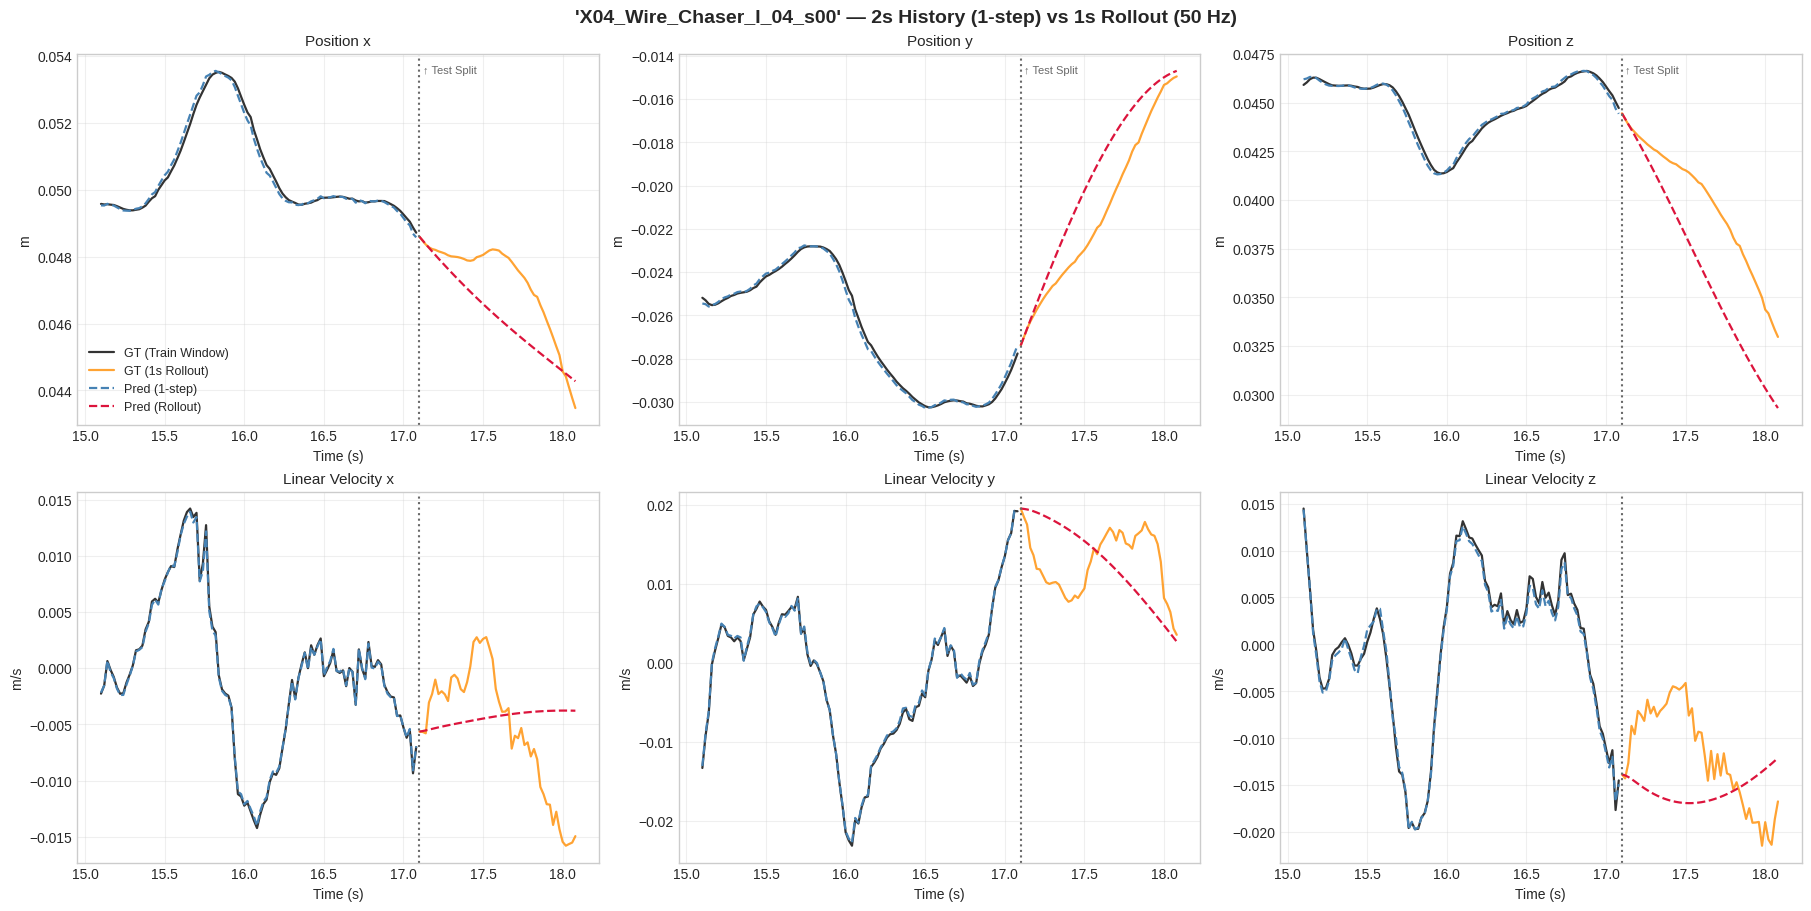

In [11]:
# ── Cell 11: Visualization & Analysis (ROSMA compatible) ───────────────────

# =============================================================================
# 1. Select a reference trial (longest one from test_segs, or fallback)
# =============================================================================
# Look for a trial with many steps – prefer test_segs for rollout visualisation
candidate_list = test_segs if test_segs else ood_segs
ref_trial = max(candidate_list, key=lambda t: len(t['states']))
print(f"Visualising trial: {ref_trial['name']} ({len(ref_trial['states'])} frames)")

# =============================================================================
# 2. Prepare Data
# =============================================================================
states = np.array(ref_trial['states'])
T = len(states)
split_idx = int(T * 0.9)                  # Last 10% for rollout

# Number of steps for the two regimes (50 Hz → 0.02 s per step)
n_steps_plot_train = 100                  # 2 seconds of 1‑step prediction history
n_steps_test = 50                         # Rollout exactly 1 second
t_boundary = split_idx * DT               # time at split

# Sub‑select indices
tr_start = max(0, split_idx - n_steps_plot_train)
et_end = min(T, split_idx + n_steps_test)

# Time vectors
t_full = np.arange(T) * DT
t_tr = t_full[tr_start:split_idx]
t_et = t_full[split_idx:et_end]

# Ground truth
true_tr = states[tr_start:split_idx]
true_et = states[split_idx:et_end]

# 1‑step teacher‑forced predictions (train window)
xt_tr_raw = states[tr_start : split_idx]        # inputs: x[t] …
pred_tr = np.asarray(eval_model(xt_tr_raw))     # … predict x[t+1]

# Rollout predictions (test window)
x0_test_raw = states[split_idx]
pred_et = np.asarray(rollout_jax(eval_model, x0_test_raw, n_steps_test))

# =============================================================================
# 3. FIGURE 1: Trajectory Rollouts
# =============================================================================
labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]      # Position indices
linvel_idx = [6, 7, 8]     # Linear velocity indices

fig, axes = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
fig.suptitle(f"'{ref_trial['name']}' — 2s History (1-step) vs 1s Rollout (50 Hz)",
             fontsize=14, fontweight='bold')

C_GT_TR, C_GT_ET = 'black', 'darkorange'
C_PR_TR, C_PR_ET = 'steelblue', 'crimson'

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes[row, j]

        # Ground Truth
        ax.plot(t_tr, true_tr[:, idxs[j]], color=C_GT_TR, lw=1.6, alpha=0.80, label='GT (Train Window)')
        ax.plot(t_et, true_et[:, idxs[j]], color=C_GT_ET, lw=1.6, alpha=0.80, label='GT (1s Rollout)')

        # Predictions
        ax.plot(t_tr, pred_tr[:, idxs[j]], '--', color=C_PR_TR, lw=1.6, label='Pred (1-step)')
        ax.plot(t_et, pred_et[:, idxs[j]], '--', color=C_PR_ET, lw=1.6, label='Pred (Rollout)')

        # Train/Test boundary
        ax.axvline(x=t_boundary, color='dimgray', ls=':', lw=1.5)
        if row == 0:
            ax.text(t_boundary + 0.02, 0.97, '↑ Test Split', ha='left', va='top',
                    transform=ax.get_xaxis_transform(), fontsize=8, color='dimgray')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(True, alpha=0.3)

        if row == 0 and j == 0:
            ax.legend(loc='best', fontsize=9)

plt.show()

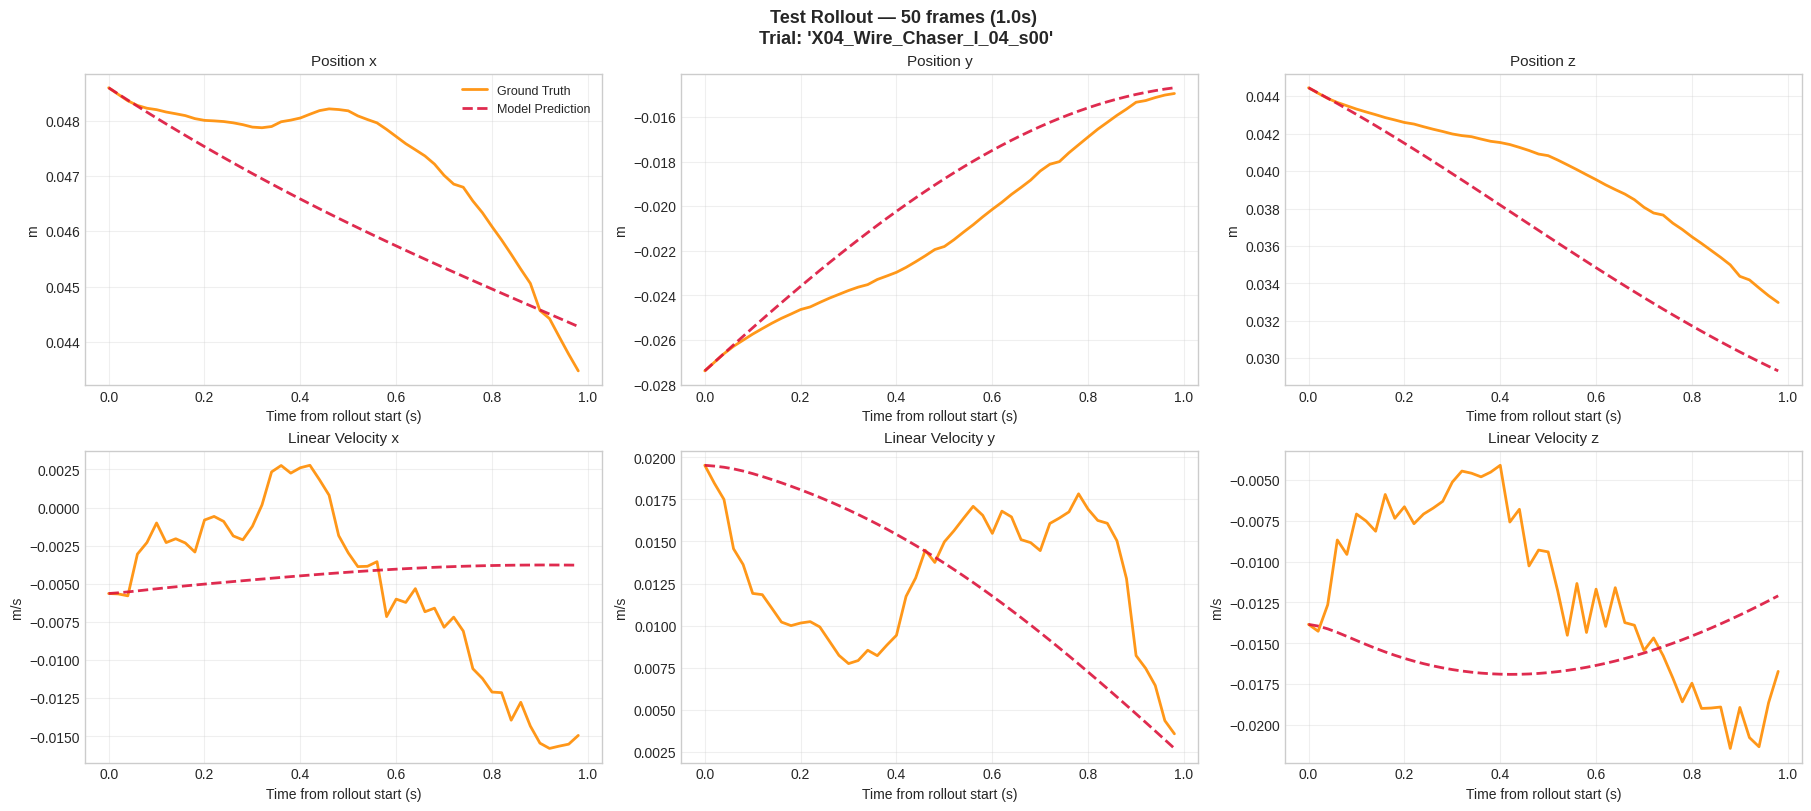

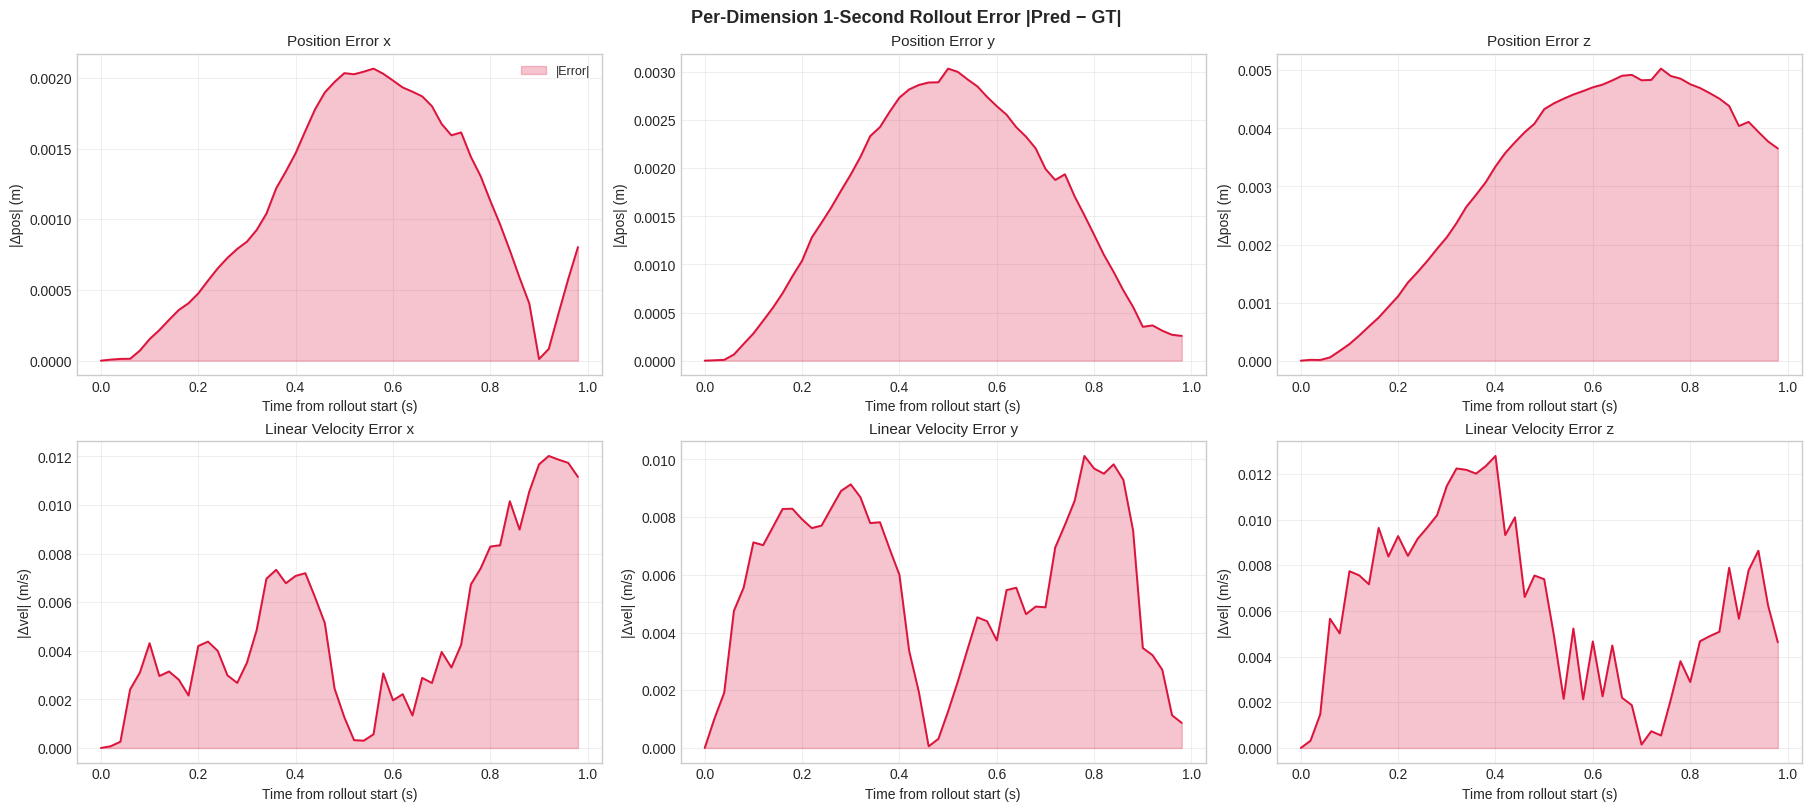

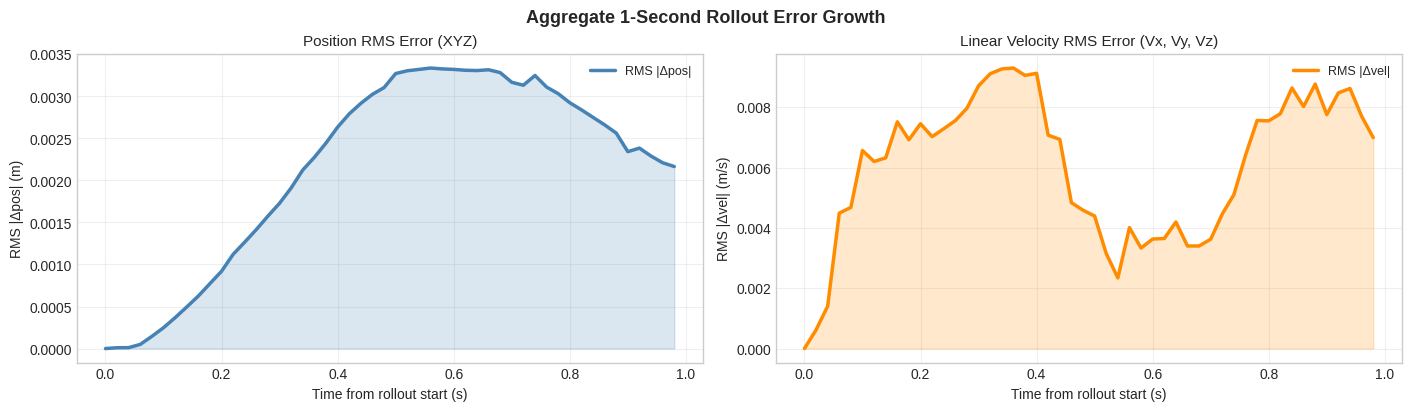


1‑SECOND ROLLOUT ANALYSIS — 50 frames (1.00s)
Trial: 'X04_Wire_Chaser_I_04_s00'
----------------------------------------------------------------------
Position RMS Error (m):
  Initial : 0.000000e+00
  Final   : 2.165235e-03
  Peak    : 3.336928e-03  (at t=0.56s)
  Mean    : 2.157994e-03
----------------------------------------------------------------------
Velocity RMS Error (m/s):
  Initial : 0.000000e+00
  Final   : 6.991213e-03
  Peak    : 9.296878e-03  (at t=0.36s)
  Mean    : 6.057865e-03
----------------------------------------------------------------------

Per-Dimension Final Errors at t=0.98s:
  X: Δpos = 8.033663e-04 m  |  Δvel = 1.115713e-02 m/s
  Y: Δpos = 2.574902e-04 m  |  Δvel = 8.685288e-04 m/s
  Z: Δpos = 3.654180e-03 m  |  Δvel = 4.625509e-03 m/s

✓ Saved visualizations:
  1. glnn_rosma_test_traj.png
  2. glnn_rosma_test_error.png
  3. glnn_rosma_test_rms_error.png



In [12]:
# ── Cell 12: Rollout Error Analysis & Visualization (ROSMA) ─────────────────

# =============================================================================
# 1. Variable Alignment (from Cell 11)
# =============================================================================
T_total = len(states)
T_tr = split_idx
T_et = len(true_et)                     # 50 frames for a 1‑second rollout at 50 Hz

# Shift time so the test plot starts at t=0
t_test_relative = t_et - t_et[0]

labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]
linvel_idx = [6, 7, 8]

# Absolute error arrays directly from unscaled raw predictions
err_et = np.abs(pred_et - true_et)      # Shape: (50, 12)

# =============================================================================
# 2. FIGURE 3: Ground Truth vs Prediction (Test Window Only)
# =============================================================================
fig3, axes3 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig3.suptitle(
    f"Test Rollout — {T_et} frames ({T_et*DT:.1f}s) \nTrial: '{ref_trial['name']}'",
    fontsize=13, fontweight='bold')

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes3[row, j]
        ax.plot(t_test_relative, true_et[:, idxs[j]], color='darkorange',
                lw=2.0, alpha=0.90, label='Ground Truth')
        ax.plot(t_test_relative, pred_et[:, idxs[j]], '--', color='crimson',
                lw=2.0, alpha=0.90, label='Model Prediction')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from rollout start (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.savefig('glnn_rosma_test_traj.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 3. FIGURE 4: Per-Dimension Absolute Error Over Time
# =============================================================================
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig4.suptitle(
    f"Per-Dimension 1‑Second Rollout Error |Pred − GT|",
    fontsize=13, fontweight='bold')

ylabels2 = ['|Δpos| (m)', '|Δvel| (m/s)']
for row, idxs, ylbl, kind in [(0, trans_idx, ylabels2[0], 'Position Error'),
                              (1, linvel_idx, ylabels2[1], 'Linear Velocity Error')]:
    for j in range(3):
        ax = axes4[row, j]
        ax.fill_between(t_test_relative, 0, err_et[:, idxs[j]],
                        color='crimson', alpha=0.25, label='|Error|')
        ax.plot(t_test_relative, err_et[:, idxs[j]], color='crimson', lw=1.4)

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from rollout start (s)')
        ax.set_ylabel(ylbl)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.savefig('glnn_rosma_test_error.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. FIGURE 5: Aggregate RMS Error Curves
# =============================================================================
pos_err_t = np.sqrt(np.mean(err_et[:, :3] ** 2, axis=1))
vel_err_t = np.sqrt(np.mean(err_et[:, 6:9] ** 2, axis=1))

fig5, ax5 = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
fig5.suptitle('Aggregate 1‑Second Rollout Error Growth', fontsize=13, fontweight='bold')

# Position error
ax5[0].plot(t_test_relative, pos_err_t, color='steelblue', lw=2.5, label='RMS |Δpos|')
ax5[0].fill_between(t_test_relative, 0, pos_err_t, alpha=0.2, color='steelblue')
ax5[0].set_title('Position RMS Error (XYZ)', fontsize=11)
ax5[0].set_xlabel('Time from rollout start (s)')
ax5[0].set_ylabel('RMS |Δpos| (m)')
ax5[0].grid(alpha=0.3)
ax5[0].legend(fontsize=9)

# Velocity error
ax5[1].plot(t_test_relative, vel_err_t, color='darkorange', lw=2.5, label='RMS |Δvel|')
ax5[1].fill_between(t_test_relative, 0, vel_err_t, alpha=0.2, color='darkorange')
ax5[1].set_title('Linear Velocity RMS Error (Vx, Vy, Vz)', fontsize=11)
ax5[1].set_xlabel('Time from rollout start (s)')
ax5[1].set_ylabel('RMS |Δvel| (m/s)')
ax5[1].grid(alpha=0.3)
ax5[1].legend(fontsize=9)

plt.savefig('glnn_rosma_test_rms_error.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 5. Summary Statistics Terminal Output
# =============================================================================
W = 70
print(f"\n{'='*W}")
print(f"1‑SECOND ROLLOUT ANALYSIS — {T_et} frames ({T_et*DT:.2f}s)")
print(f"{'='*W}")
print(f"Trial: '{ref_trial['name']}'")
print(f"-" * W)
print(f"Position RMS Error (m):")
print(f"  Initial : {pos_err_t[0]:.6e}")
print(f"  Final   : {pos_err_t[-1]:.6e}")
print(f"  Peak    : {pos_err_t.max():.6e}  (at t={t_test_relative[pos_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {pos_err_t.mean():.6e}")
print(f"-" * W)
print(f"Velocity RMS Error (m/s):")
print(f"  Initial : {vel_err_t[0]:.6e}")
print(f"  Final   : {vel_err_t[-1]:.6e}")
print(f"  Peak    : {vel_err_t.max():.6e}  (at t={t_test_relative[vel_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {vel_err_t.mean():.6e}")
print(f"-" * W)

# Per-dimension analysis breakdown
print(f"\nPer-Dimension Final Errors at t={t_test_relative[-1]:.2f}s:")
for i, label in enumerate(labels):
    pos_err_final = err_et[-1, i]
    vel_err_final = err_et[-1, 6+i]
    print(f"  {label.upper()}: Δpos = {pos_err_final:.6e} m  |  Δvel = {vel_err_final:.6e} m/s")

print(f"\n✓ Saved visualizations:")
print(f"  1. glnn_rosma_test_traj.png")
print(f"  2. glnn_rosma_test_error.png")
print(f"  3. glnn_rosma_test_rms_error.png")
print(f"{'='*W}\n")

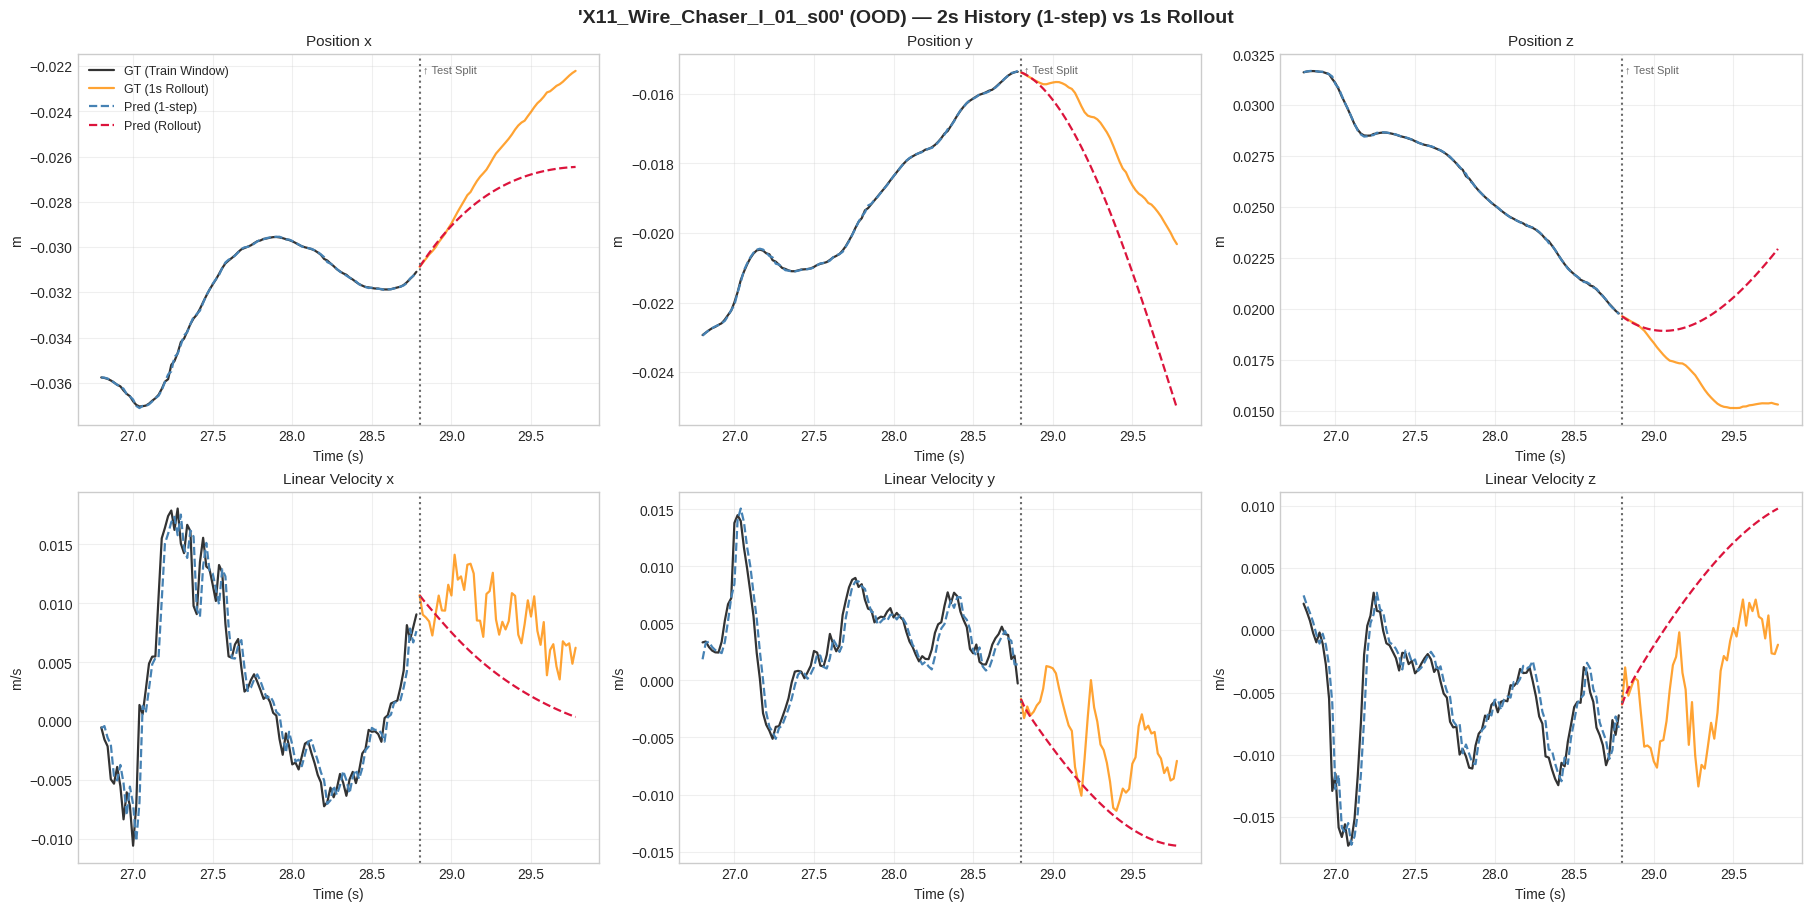

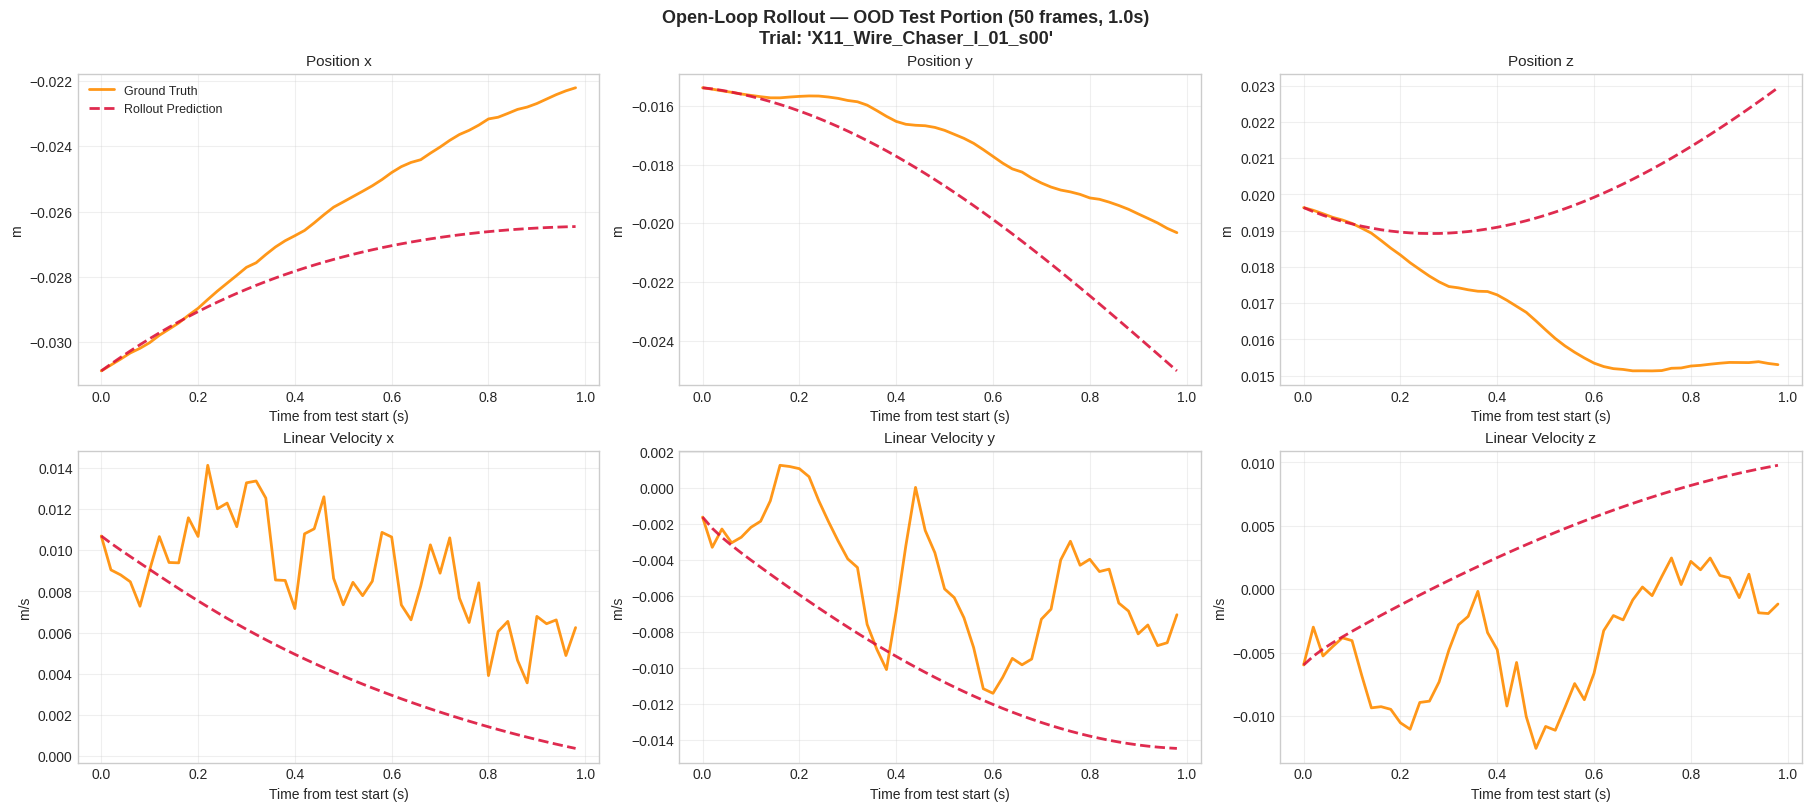

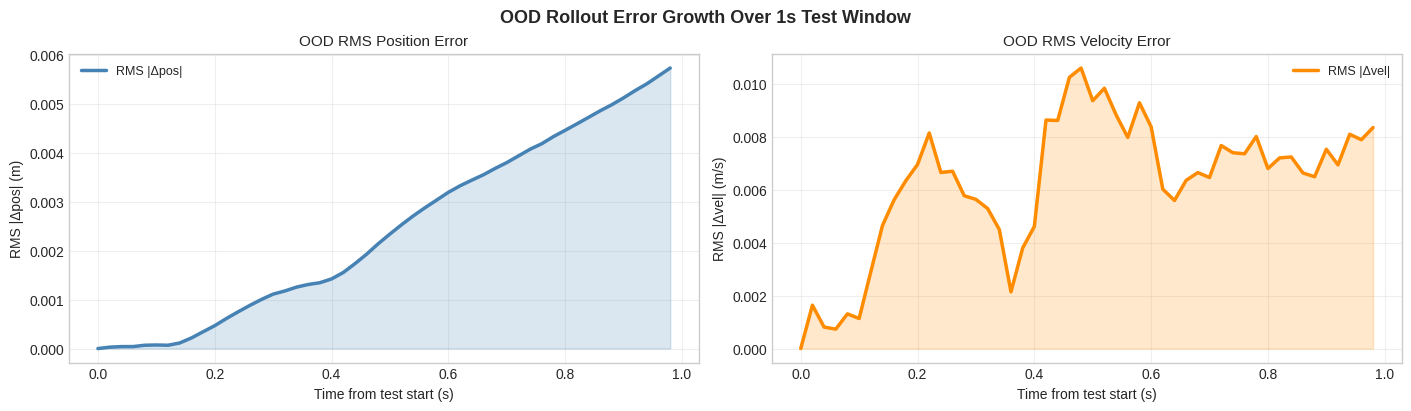


OOD ROLLOUT ERROR ANALYSIS — 50 frames (1.00s)
Trial: X11_Wire_Chaser_I_01_s00
----------------------------------------------------------------------
Position RMS Error (m):
  Initial : 0.000000e+00
  Final   : 5.735643e-03
  Peak    : 5.735643e-03  (at t=0.98s)
  Mean    : 2.429504e-03
----------------------------------------------------------------------
Velocity RMS Error (m/s):
  Initial : 0.000000e+00
  Final   : 8.352692e-03
  Peak    : 1.060044e-02  (at t=0.48s)
  Mean    : 6.237503e-03
----------------------------------------------------------------------

TEST (ID) vs OOD GENERALIZATION GAP
Position Error Growth:
  Test (ID) final : 2.165235e-03 m
  OOD final       : 5.735643e-03 m
  Ratio (OOD/ID)  : 2.65×

Velocity Error Growth:
  Test (ID) final : 6.991213e-03 m/s
  OOD final       : 8.352692e-03 m/s
  Ratio (OOD/ID)  : 1.19×

✓ Saved OOD visualizations:
  1. glnn_ood_traj.png
  2. glnn_ood_test_traj.png
  3. glnn_ood_test_rms_error.png


In [13]:
# ── Cell 13: OOD Trajectories & Error Analysis (ROSMA) ──────────────────────

# =============================================================================
# 1. Prepare Data: Generate OOD Predictions (RAW STATES)
# =============================================================================
# Select the longest OOD trial (X11/X12) for visualisation
ood_ref_trial = max(ood_segs, key=lambda t: len(t['states']))
ood_states = np.array(ood_ref_trial['states'])
ood_total = len(ood_states)
ood_tr_len = int(ood_total * 0.9)          # 90/10 split

# Rollout horizon: 1 second (50 frames at 50 Hz)
horizon_frames = min(ood_total - ood_tr_len, 50)
ood_t_boundary = ood_tr_len * DT

# Time vectors
ood_t_full = np.arange(ood_total) * DT
ood_t_tr = ood_t_full[:ood_tr_len]
ood_t_et = ood_t_full[ood_tr_len : ood_tr_len + horizon_frames]
ood_t_test_relative = ood_t_et - ood_t_et[0]   # Start at 0 for isolated plot

# Ground truth
ood_true_tr = ood_states[:ood_tr_len]
ood_true_et = ood_states[ood_tr_len : ood_tr_len + horizon_frames]

# 1‑step teacher‑forced predictions (OOD “train” portion)
ood_xt_tr_raw = ood_states[:ood_tr_len-1]
ood_pred_tr = np.asarray(eval_model(ood_xt_tr_raw))
ood_pred_tr = np.vstack([ood_states[0], ood_pred_tr])   # prepend initial state

# Rollout predictions (OOD test portion)
ood_x0_test_raw = ood_states[ood_tr_len]
ood_pred_et = np.asarray(rollout_jax(eval_model, ood_x0_test_raw, horizon_frames))

# Absolute errors
ood_err_et = np.abs(ood_pred_et - ood_true_et)

# Labels
labels = ['x', 'y', 'z']
trans_idx = [0, 1, 2]      # Position indices
linvel_idx = [6, 7, 8]     # Linear velocity indices

# =============================================================================
# 2. ZOOM LOGIC: Show only 2 seconds of Teacher-Forced data before the split
# =============================================================================
zoom_seconds = 2.0
zoom_frames = int(zoom_seconds / DT)    # 100 frames
zoom_start = max(0, ood_tr_len - zoom_frames)

ood_t_tr_zoom = ood_t_tr[zoom_start:]
ood_true_tr_zoom = ood_true_tr[zoom_start:]
ood_pred_tr_zoom = ood_pred_tr[zoom_start:]

# =============================================================================
# 3. FIGURE O1: OOD Train + Test on Same Axes (Zoomed)
# =============================================================================
fig_o1, axes_o1 = plt.subplots(2, 3, figsize=(18, 9), constrained_layout=True)
fig_o1.suptitle(f"'{ood_ref_trial['name']}' (OOD) — 2s History (1‑step) vs 1s Rollout",
                fontsize=14, fontweight='bold')

C_GT_TR, C_GT_ET = 'black', 'darkorange'
C_PR_TR, C_PR_ET = 'steelblue', 'crimson'

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes_o1[row, j]
        # Ground truth
        ax.plot(ood_t_tr_zoom, ood_true_tr_zoom[:, idxs[j]], color=C_GT_TR, lw=1.6, alpha=0.80,
                label='GT (Train Window)')
        ax.plot(ood_t_et, ood_true_et[:, idxs[j]], color=C_GT_ET, lw=1.6, alpha=0.80,
                label='GT (1s Rollout)')
        # Predictions
        ax.plot(ood_t_tr_zoom, ood_pred_tr_zoom[:, idxs[j]], '--', color=C_PR_TR, lw=1.6,
                label='Pred (1‑step)')
        ax.plot(ood_t_et, ood_pred_et[:, idxs[j]], '--', color=C_PR_ET, lw=1.6,
                label='Pred (Rollout)')

        ax.axvline(x=ood_t_boundary, color='dimgray', ls=':', lw=1.5)
        if row == 0:
            ax.text(ood_t_boundary + 0.02, 0.97, '↑ Test Split', ha='left', va='top',
                    transform=ax.get_xaxis_transform(), fontsize=8, color='dimgray')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9, loc='best')

plt.savefig('glnn_ood_traj.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 4. FIGURE O2: OOD Test Portion Only (Rollout)
# =============================================================================
fig_o2, axes_o2 = plt.subplots(2, 3, figsize=(18, 8), constrained_layout=True)
fig_o2.suptitle(
    f"Open‑Loop Rollout — OOD Test Portion ({horizon_frames} frames, {horizon_frames*DT:.1f}s)\n"
    f"Trial: '{ood_ref_trial['name']}'",
    fontsize=13, fontweight='bold')

for row, idxs, ylabel, kind in [(0, trans_idx, 'm', 'Position'),
                                (1, linvel_idx, 'm/s', 'Linear Velocity')]:
    for j in range(3):
        ax = axes_o2[row, j]
        ax.plot(ood_t_test_relative, ood_true_et[:, idxs[j]], color='darkorange',
                lw=2.0, alpha=0.90, label='Ground Truth')
        ax.plot(ood_t_test_relative, ood_pred_et[:, idxs[j]], '--', color='crimson',
                lw=2.0, alpha=0.90, label='Rollout Prediction')

        ax.set_title(f'{kind} {labels[j]}', fontsize=11)
        ax.set_xlabel('Time from test start (s)')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        if row == 0 and j == 0:
            ax.legend(fontsize=9)

plt.savefig('glnn_ood_test_traj.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 5. FIGURE O3: Aggregate RMS Error Curves
# =============================================================================
# RMS over 3D dimensions
ood_pos_err_t = np.sqrt(np.mean(ood_err_et[:, :3] ** 2, axis=1))   # Position
ood_vel_err_t = np.sqrt(np.mean(ood_err_et[:, 6:9] ** 2, axis=1))  # Linear velocity

fig_o3, ax_o3 = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)
fig_o3.suptitle('OOD Rollout Error Growth Over 1s Test Window', fontsize=13, fontweight='bold')

# Position error
ax_o3[0].plot(ood_t_test_relative, ood_pos_err_t, color='steelblue', lw=2.5, label='RMS |Δpos|')
ax_o3[0].fill_between(ood_t_test_relative, 0, ood_pos_err_t, alpha=0.2, color='steelblue')
ax_o3[0].set_title('OOD RMS Position Error', fontsize=11)
ax_o3[0].set_xlabel('Time from test start (s)')
ax_o3[0].set_ylabel('RMS |Δpos| (m)')
ax_o3[0].grid(alpha=0.3)
ax_o3[0].legend(fontsize=9)

# Velocity error
ax_o3[1].plot(ood_t_test_relative, ood_vel_err_t, color='darkorange', lw=2.5, label='RMS |Δvel|')
ax_o3[1].fill_between(ood_t_test_relative, 0, ood_vel_err_t, alpha=0.2, color='darkorange')
ax_o3[1].set_title('OOD RMS Velocity Error', fontsize=11)
ax_o3[1].set_xlabel('Time from test start (s)')
ax_o3[1].set_ylabel('RMS |Δvel| (m/s)')
ax_o3[1].grid(alpha=0.3)
ax_o3[1].legend(fontsize=9)

plt.savefig('glnn_ood_test_rms_error.png', dpi=150, bbox_inches='tight')
plt.show()

# =============================================================================
# 6. Summary Statistics Terminal Output
# =============================================================================
W = 70
print(f"\n{'='*W}")
print(f"OOD ROLLOUT ERROR ANALYSIS — {horizon_frames} frames ({horizon_frames*DT:.2f}s)")
print(f"{'='*W}")
print(f"Trial: {ood_ref_trial['name']}")
print(f"-" * W)
print(f"Position RMS Error (m):")
print(f"  Initial : {ood_pos_err_t[0]:.6e}")
print(f"  Final   : {ood_pos_err_t[-1]:.6e}")
print(f"  Peak    : {ood_pos_err_t.max():.6e}  (at t={ood_t_test_relative[ood_pos_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {ood_pos_err_t.mean():.6e}")
print(f"-" * W)
print(f"Velocity RMS Error (m/s):")
print(f"  Initial : {ood_vel_err_t[0]:.6e}")
print(f"  Final   : {ood_vel_err_t[-1]:.6e}")
print(f"  Peak    : {ood_vel_err_t.max():.6e}  (at t={ood_t_test_relative[ood_vel_err_t.argmax()]:.2f}s)")
print(f"  Mean    : {ood_vel_err_t.mean():.6e}")
print(f"-" * W)

# Comparison: Test (ID) vs OOD (Generalization Gap)
try:
    print(f"\n{'='*W}")
    print(f"TEST (ID) vs OOD GENERALIZATION GAP")
    print(f"{'='*W}")
    print(f"Position Error Growth:")
    print(f"  Test (ID) final : {pos_err_t[-1]:.6e} m")
    print(f"  OOD final       : {ood_pos_err_t[-1]:.6e} m")
    print(f"  Ratio (OOD/ID)  : {ood_pos_err_t[-1] / max(pos_err_t[-1], 1e-10):.2f}×")
    print(f"\nVelocity Error Growth:")
    print(f"  Test (ID) final : {vel_err_t[-1]:.6e} m/s")
    print(f"  OOD final       : {ood_vel_err_t[-1]:.6e} m/s")
    print(f"  Ratio (OOD/ID)  : {ood_vel_err_t[-1] / max(vel_err_t[-1], 1e-10):.2f}×")
    print(f"{'='*W}")
except NameError:
    print("\n[!] Test error variables (pos_err_t) not found. Run Cell 12 first to see ID/OOD Comparison.")

print(f"\n✓ Saved OOD visualizations:")
print(f"  1. glnn_ood_traj.png")
print(f"  2. glnn_ood_test_traj.png")
print(f"  3. glnn_ood_test_rms_error.png")

In [14]:
# ── Cell 14: Compute Dataset-Wide 1-Second Rollout Errors (ROSMA) ────────────
import numpy as np

def compute_dataset_rollout_error(eval_wrapper, trials, scale_array, horizon_frames=50, step_size=50):
    """
    Computes the Filtered Mean Squared rollout error across the specified dataset.
    Uses raw state inputs, ensuring mathematical stability.
    """
    all_window_errors = []

    for t in trials:
        raw_states = np.array(t['states'])
        T = len(raw_states)

        # Slide a window across the entire trial
        for start_idx in range(0, T - horizon_frames, step_size):
            x0_raw = raw_states[start_idx]
            true_traj = raw_states[start_idx : start_idx + horizon_frames]

            # Predict using raw states directly (ensuring clean JAX array conversion)
            pred_traj = np.asarray(rollout_jax(eval_wrapper, x0_raw, horizon_frames))

            # Scaled MSE: err = ((pred - true) / scale)**2
            err = ((pred_traj - true_traj) / scale_array)**2
            window_mse = np.mean(err)

            # Clip exploding trajectories so they don't corrupt the entire array with NaNs/Infs
            if np.isnan(window_mse) or np.isinf(window_mse):
                window_mse = 1e6

            all_window_errors.append(float(window_mse))

    all_window_errors = np.array(all_window_errors)

    # Calculate raw means
    raw_mean = float(np.mean(all_window_errors))

    # Filter out the top 1% outliers (numerical explosions)
    threshold = np.percentile(all_window_errors, 99.0)
    filtered_errors = all_window_errors[all_window_errors <= threshold]
    filtered_mean = float(np.mean(filtered_errors))

    # Calculate Outliers Percentage (Windows with scaled MSE > 100.0)
    outlier_percent = float(np.sum(all_window_errors > 100.0) / len(all_window_errors) * 100)

    return raw_mean, filtered_mean, outlier_percent

print("\nComputing 1-second Rollout Errors across the entire dataset...")

# Ensure normalization stats are available (re-initialized from previous cells if needed)
if 'state_std' not in globals():
    state_mean = np.mean(x_tr, axis=0)
    state_std = np.std(x_tr, axis=0)
    state_std = np.where(state_std < 1e-8, 1.0, state_std)

# We use state_std as the physical scale for velocity/position units
scale_array = np.array(state_std, dtype=np.float32)

# Execute on the ROSMA segments (use train_segs, test_segs, ood_segs)
ro_tr_mean, ro_tr_filt, ro_tr_out = compute_dataset_rollout_error(eval_model, train_segs, scale_array)
ro_nt_mean, ro_nt_filt, ro_nt_out = compute_dataset_rollout_error(eval_model, test_segs, scale_array)
ro_et_mean, ro_et_filt, ro_et_out = compute_dataset_rollout_error(eval_model, ood_segs, scale_array)

W = 105
print(f'\n{"="*W}')
print(f'{"1-SECOND ROLLOUT SCALED MSE (Dataset-Wide) — ROSMA":^{W}}')
print(f'{"="*W}')
print(f'  Train (ID)                : Raw Mean {ro_tr_mean:.4e} | Filtered Mean {ro_tr_filt:.4e} | Outliers: {ro_tr_out:.2f}%')
print(f'  Test (ID)                 : Raw Mean {ro_nt_mean:.4e} | Filtered Mean {ro_nt_filt:.4e} | Outliers: {ro_nt_out:.2f}%')
print(f'  Test (OOD)                : Raw Mean {ro_et_mean:.4e} | Filtered Mean {ro_et_filt:.4e} | Outliers: {ro_et_out:.2f}%')
print(f'{"="*W}\n')


Computing 1-second Rollout Errors across the entire dataset...

                           1-SECOND ROLLOUT SCALED MSE (Dataset-Wide) — ROSMA                            
  Train (ID)                : Raw Mean 4.4734e-01 | Filtered Mean 4.0574e-01 | Outliers: 0.00%
  Test (ID)                 : Raw Mean 3.4821e-01 | Filtered Mean 3.1391e-01 | Outliers: 0.00%
  Test (OOD)                : Raw Mean 2.8225e-01 | Filtered Mean 2.6915e-01 | Outliers: 0.00%



In [17]:
# ── Cell 15: Final Summary Table (ROSMA) ─────────────────────────────────────

# Calculate generalization gap safely (OOD vs ID Train)
if mse_tr_filt > 0:
    gen_gap = ((mse_et_filt - mse_tr_filt) / mse_tr_filt) * 100.0
else:
    gen_gap = 0.0

# OOD / ID η ratio (OOD test vs ID train)
eta_ratio = eta_et_filt / eta_tr_filt if eta_tr_filt > 0 else 0.0

W = 85
print(f'\n{"="*W}')
print(f'{"FINAL SUMMARY TABLE — GLNN on ROSMA":^{W}}')
print(f'{"="*W}')
print(f'  Data source   : REAL ROSMA (dVRK kinematics + Hardware Wrench Forces)')
print(f'  Paradigm      : Train on ID subjects (LOUO), Test on OOD subjects (X11, X12)')
print(f'  Architecture  : L-net + F-net (JAX/Flax Compiled + MASS)')
print(f'')
print(f'  One-step MSE – ID (Train)                  {mse_tr_filt:.6e}  (Outliers: {out_tr:.2f}%)')
print(f'  One-step MSE – ID (Test, In-Dist)          {mse_nt_filt:.6e}  (Outliers: {out_nt:.2f}%)')
print(f'  One-step MSE – OOD (Test)                  {mse_et_filt:.6e}  (Outliers: {out_et:.2f}%)')
print(f'  Generalization Gap (OOD vs ID Train)       {gen_gap:.2f} %')
print(f'')
print(f'  1-Second Rollout MSE – ID (Train)          {ro_tr_filt:.6e}  (Outliers: {ro_tr_out:.2f}%)')
print(f'  1-Second Rollout MSE – ID (Test)           {ro_nt_filt:.6e}  (Outliers: {ro_nt_out:.2f}%)')
print(f'  1-Second Rollout MSE – OOD (Test)          {ro_et_filt:.6e}  (Outliers: {ro_et_out:.2f}%)')
print(f'')
print(f'  η ID (Train) (Filtered Mean |F_nc|)        {eta_tr_filt:.6e}')
print(f'  η OOD (Test) (Filtered Mean |F_nc|)        {eta_et_filt:.6e}')
print(f'  OOD / ID η ratio                           {eta_ratio:.2f} ×')
print(f'')
print(f'  Physics Discovery (Inferred η vs Hardware Wrench Force):')
print(f'  ID (Train) Correlation (r)                 {corr_tr:+.3f}  (Mean Wrench: {w_tr_mean:.4f} N)')
print(f'  ID (Test)  Correlation (r)                 {corr_nt:+.3f}  (Mean Wrench: {w_nt_mean:.4f} N)')
print(f'  OOD (Test) Correlation (r)                 {corr_et:+.3f}  (Mean Wrench: {w_et_mean:.4f} N)')
print(f'{"="*W}')
print(f'  Notes:')
print(f'   • Train on ID subjects (X01–X10) with LOUO split, test on OOD (X11, X12).')
print(f'   • Rollouts bounded to 1.0 second (50 frames) to prevent open-loop drift.')
print(f'   • Correlation (r) > 0.5 indicates successful physical force discovery.')
print(f'{"="*W}\n')


                         FINAL SUMMARY TABLE — GLNN on ROSMA                         
  Data source   : REAL ROSMA (dVRK kinematics + Hardware Wrench Forces)
  Paradigm      : Train on ID subjects (LOUO), Test on OOD subjects (X11, X12)
  Architecture  : L-net + F-net (JAX/Flax Compiled + MASS)

  One-step MSE – ID (Train)                  5.899844e-02  (Outliers: 0.66%)
  One-step MSE – ID (Test, In-Dist)          5.127440e-02  (Outliers: 0.43%)
  One-step MSE – OOD (Test)                  4.622710e-02  (Outliers: 0.16%)
  Generalization Gap (OOD vs ID Train)       -21.65 %

  1-Second Rollout MSE – ID (Train)          4.057442e-01  (Outliers: 0.00%)
  1-Second Rollout MSE – ID (Test)           3.139056e-01  (Outliers: 0.00%)
  1-Second Rollout MSE – OOD (Test)          2.691502e-01  (Outliers: 0.00%)

  η ID (Train) (Filtered Mean |F_nc|)        2.735454e-01
  η OOD (Test) (Filtered Mean |F_nc|)        2.400046e-01
  OOD / ID η ratio                           0.88 ×

  Physics Disco

Generating Force Discovery Overlays...


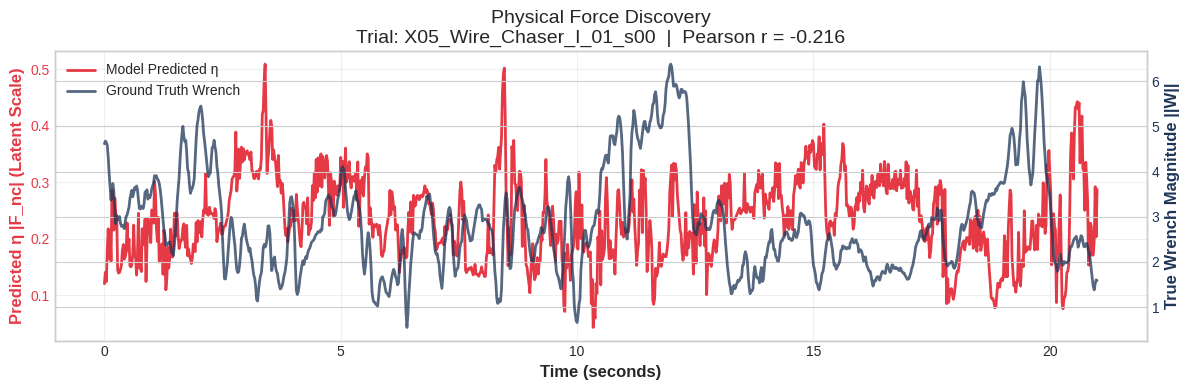

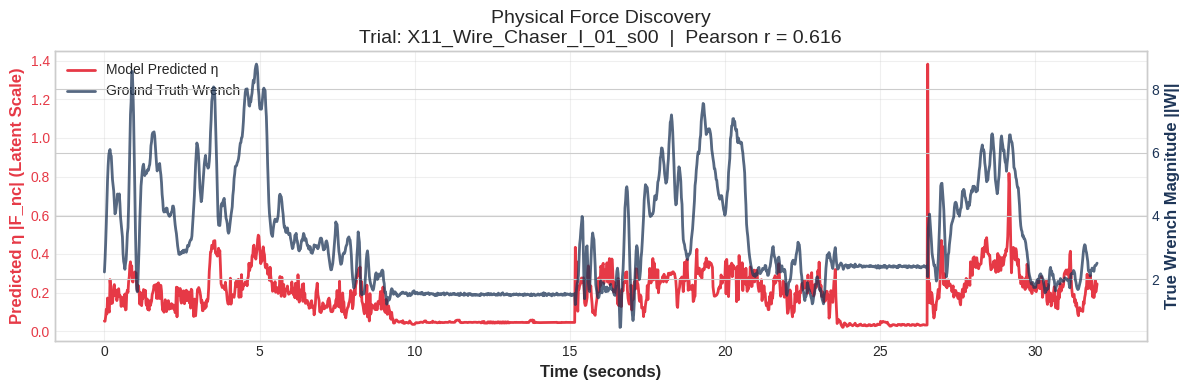

In [19]:
# ── Cell 10: Visualizing Physical Discovery (Eta vs Ground Truth Wrench) ──

import matplotlib.pyplot as plt

def plot_force_discovery(model, params_ensemble, trials_to_plot, state_mean, state_std, system_idx=0, fps=50):
    """
    Plots the model-predicted non-conservative forces (η) against the
    ground-truth robot wrench forces to visually confirm physical discovery.
    """
    # Extract parameters for the specific ensemble agent
    params_sys = jax.tree_util.tree_map(lambda x: x[system_idx], params_ensemble)

    for t in trials_to_plot:
        name = t['name']
        states = t['states']
        wrench = t['wrench']

        # 1. Ground Truth Wrench Magnitude (6-DOF: 3 Force + 3 Torque)
        w_mag = np.linalg.norm(wrench, axis=-1)

        # 2. Predicted Eta (F_nc magnitude)
        s_n = (states - state_mean) / state_std

        chunk = 512
        eta_pred = []
        for i in range(0, len(s_n), chunk):
            s_batch = s_n[i:i+chunk]
            actual_len = len(s_batch)

            # Static padding to prevent JAX compilation storm
            if actual_len < chunk:
                pad_width = ((0, chunk - actual_len), (0, 0))
                s_batch_padded = np.pad(s_batch, pad_width, mode='constant')
                s_jax = jnp.array(s_batch_padded, dtype=jnp.float32)
                mag = np.array(_compute_force_magnitude_batch(model, params_sys, s_jax))
                eta_pred.append(mag[:actual_len])
            else:
                s_jax = jnp.array(s_batch, dtype=jnp.float32)
                eta_pred.append(np.array(_compute_force_magnitude_batch(model, params_sys, s_jax)))

        eta_pred = np.concatenate(eta_pred)

        # Safely calculate Pearson correlation (r)
        valid_idx = np.isfinite(eta_pred) & np.isfinite(w_mag)
        r_val = 0.0
        if np.any(valid_idx):
            r_val = np.corrcoef(eta_pred[valid_idx], w_mag[valid_idx])[0, 1]

        # 3. Plotting with Twin Axes (Different Scales)
        time_axis = np.arange(len(w_mag)) / fps

        fig, ax1 = plt.subplots(figsize=(12, 4))

        # Axis 1: Predicted Eta (Red)
        color1 = '#e63946'
        ax1.set_xlabel('Time (seconds)', fontsize=12, fontweight='bold')
        ax1.set_ylabel('Predicted η |F_nc| (Latent Scale)', color=color1, fontsize=12, fontweight='bold')
        line1 = ax1.plot(time_axis, eta_pred, color=color1, label='Model Predicted η', linewidth=2)
        ax1.tick_params(axis='y', labelcolor=color1)

        # Axis 2: Ground Truth Wrench (Blue)
        ax2 = ax1.twinx()
        color2 = '#1d3557'
        ax2.set_ylabel('True Wrench Magnitude ||W||', color=color2, fontsize=12, fontweight='bold')
        line2 = ax2.plot(time_axis, w_mag, color=color2, label='Ground Truth Wrench', linewidth=2, alpha=0.75)
        ax2.tick_params(axis='y', labelcolor=color2)

        # Formatting
        plt.title(f'Physical Force Discovery\nTrial: {name}  |  Pearson r = {r_val:.3f}', fontsize=14)

        # Combine legends from both axes
        lines = line1 + line2
        labels = [l.get_label() for l in lines]
        ax1.legend(lines, labels, loc='upper left', framealpha=0.9)

        ax1.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

# --- Execution ---
# Select a few interesting trials to visualize (e.g., 1 from Train, 1 from OOD Test)
# Make sure DVRK_FPS is available from your earlier cells (50 Hz)
print("Generating Force Discovery Overlays...")

# Grab the longest Train and longest OOD segment for the best visual representation
viz_trials = [
    max(train_segs, key=lambda x: x['length']),
    max(ood_segs, key=lambda x: x['length'])
]

plot_force_discovery(
    model=dnn,
    params_ensemble=final_params,
    trials_to_plot=viz_trials,
    state_mean=state_mean,
    state_std=state_std,
    fps=DVRK_FPS
)

Curating segments for Force Discovery Overlays...
Selected 5 from Train (LOUO) Split.
Selected 5 from Test (In-Distribution) Split.
Selected 5 from Test (Out-of-Distribution) Split.

Generating 15 mixed Force Discovery plots...


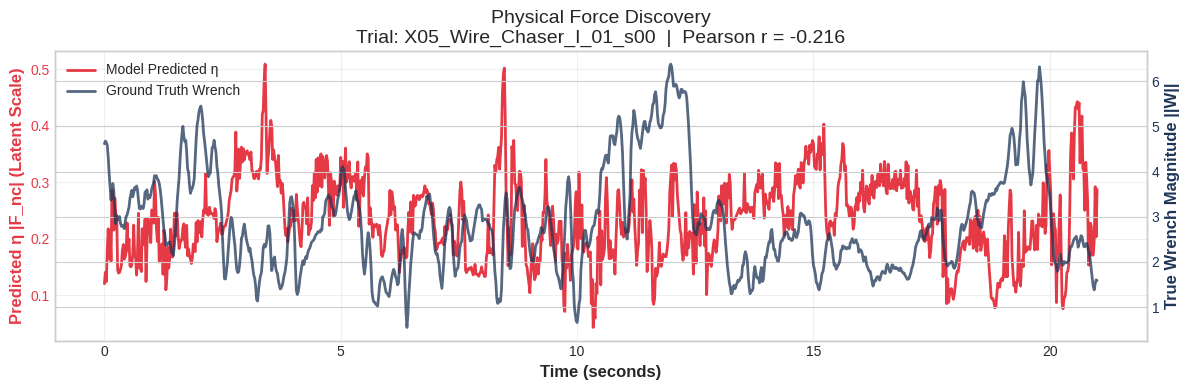

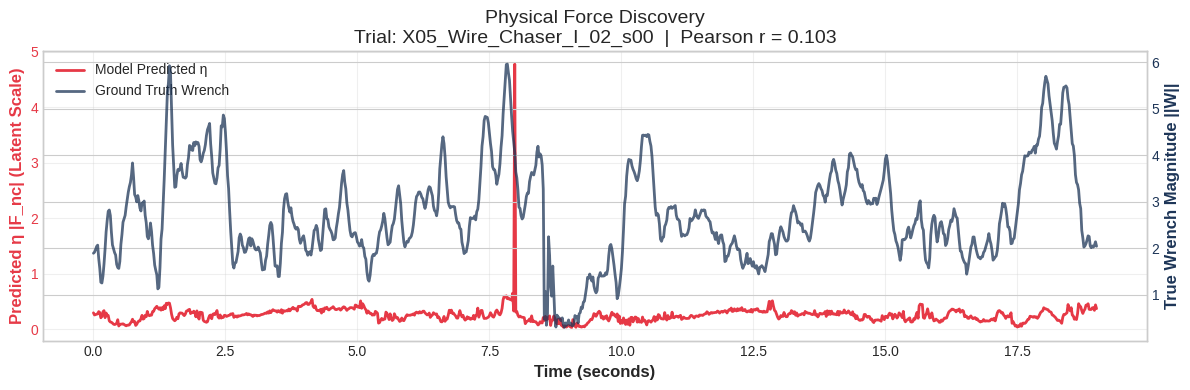

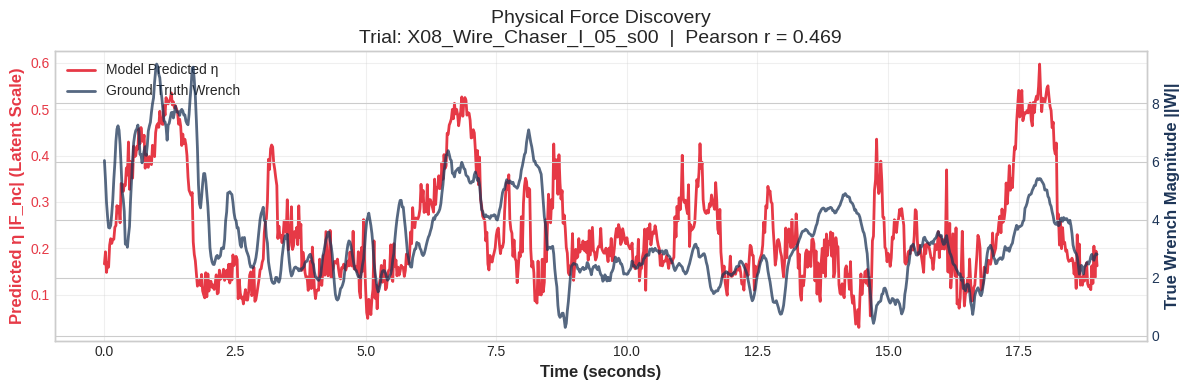

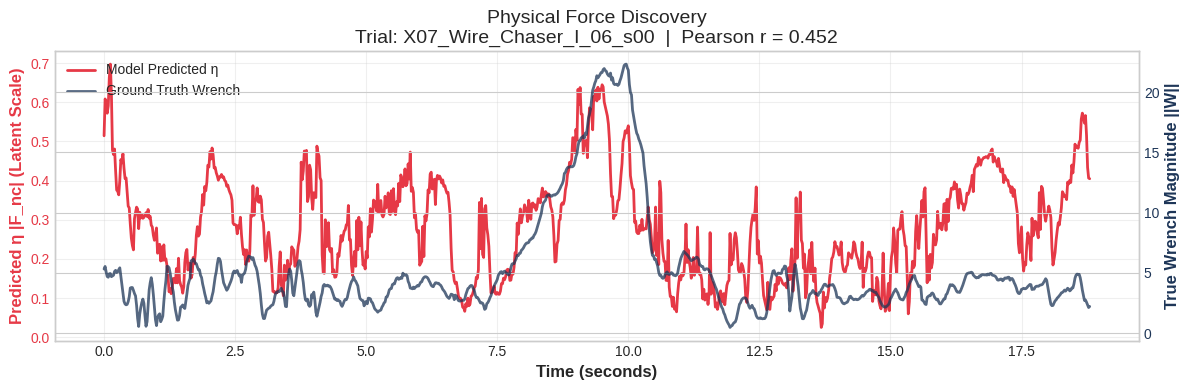

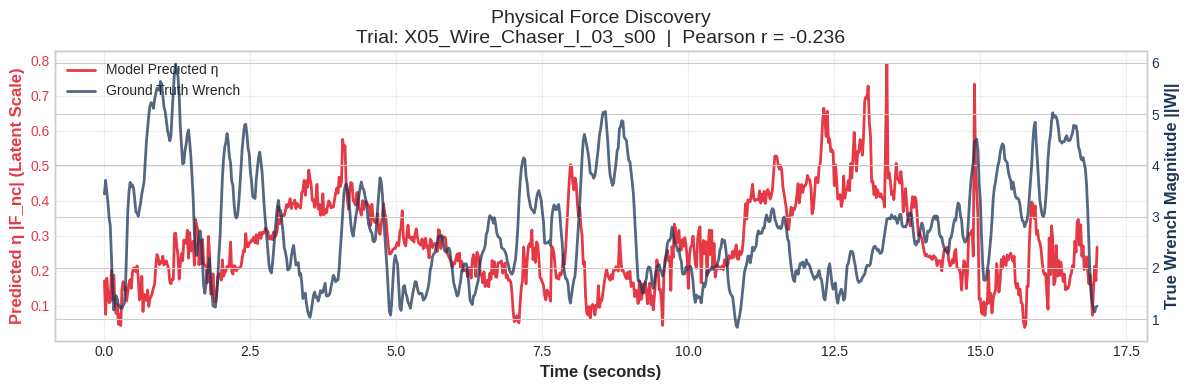

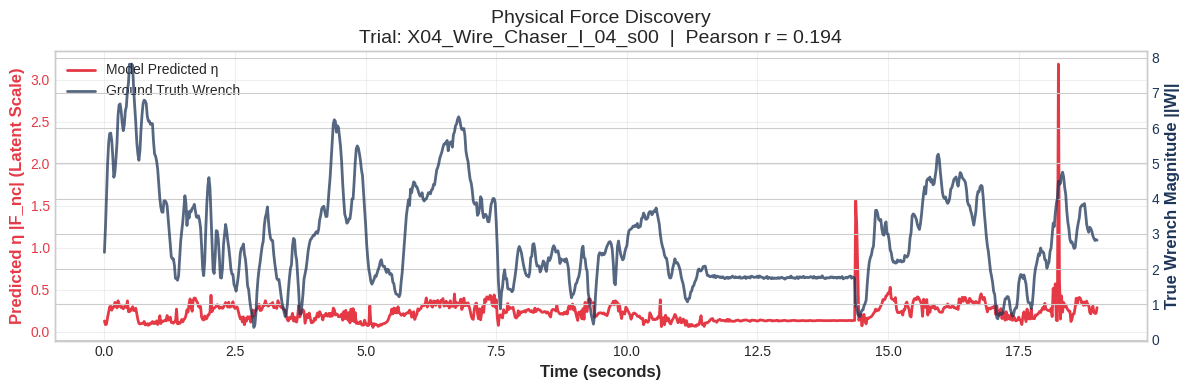

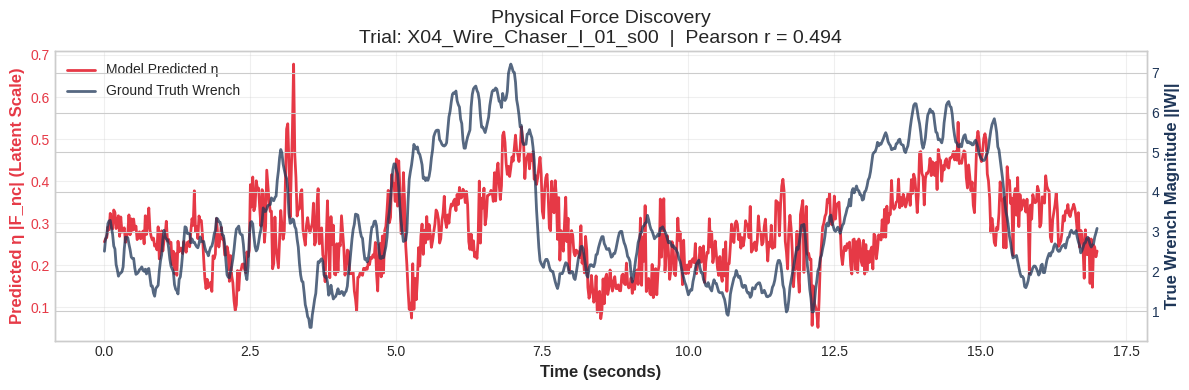

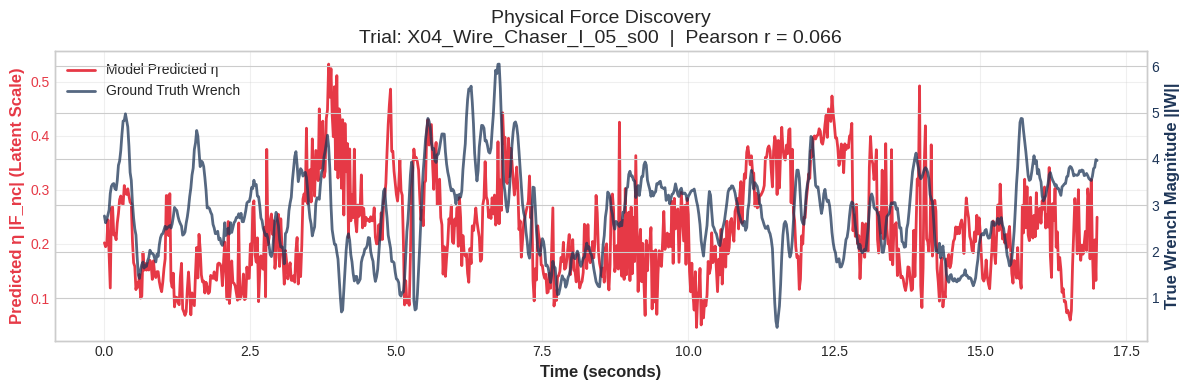

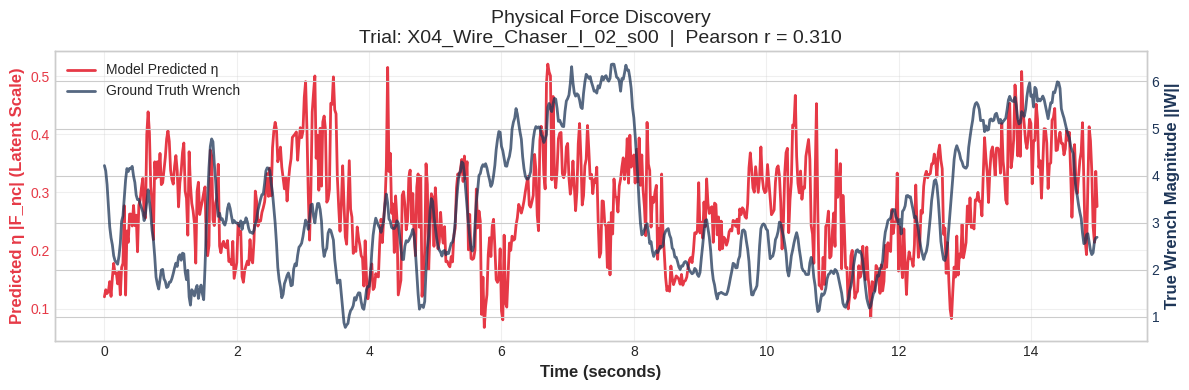

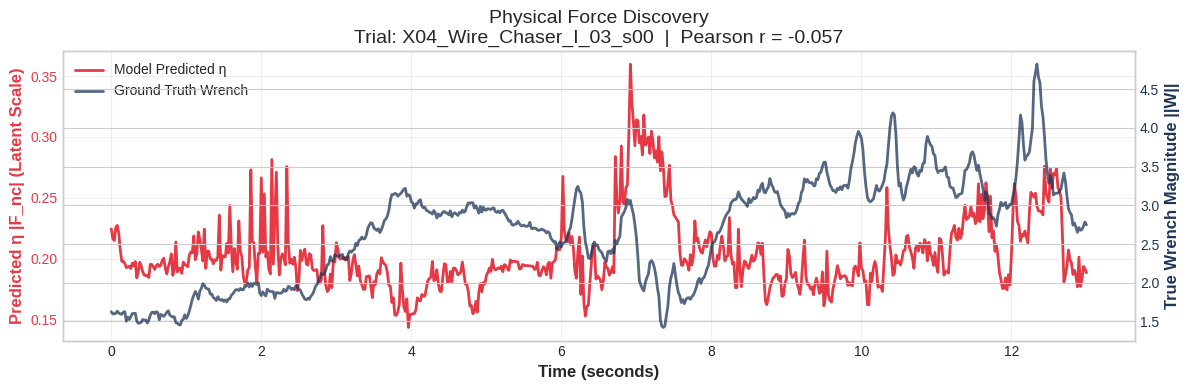

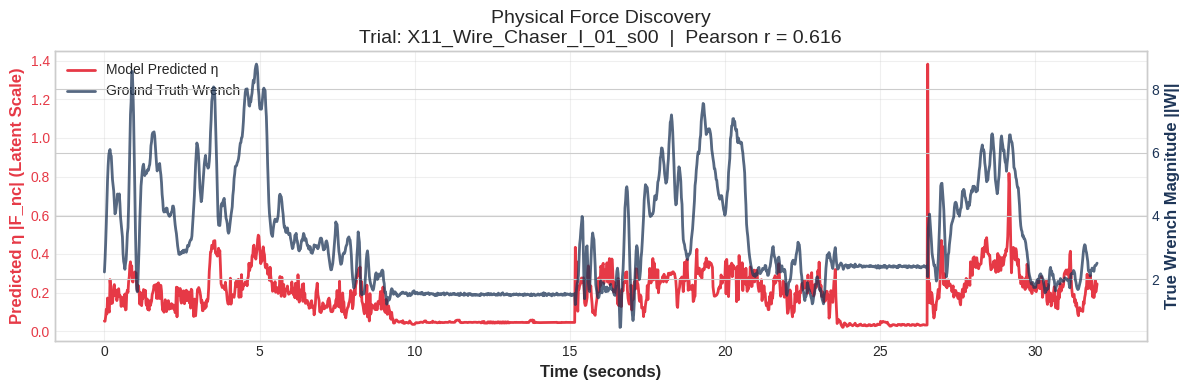

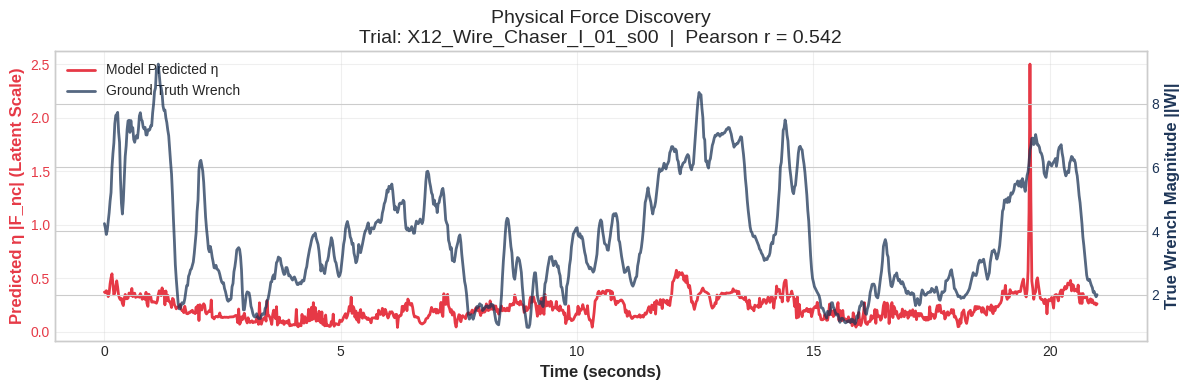

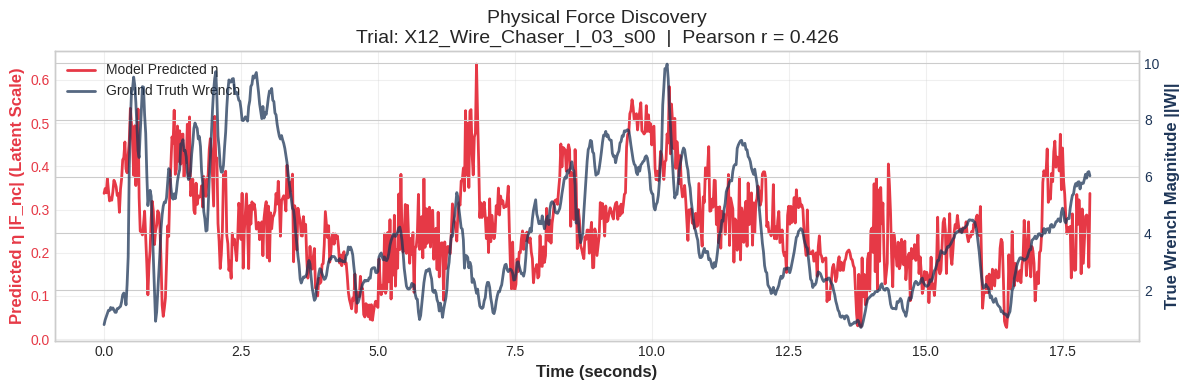

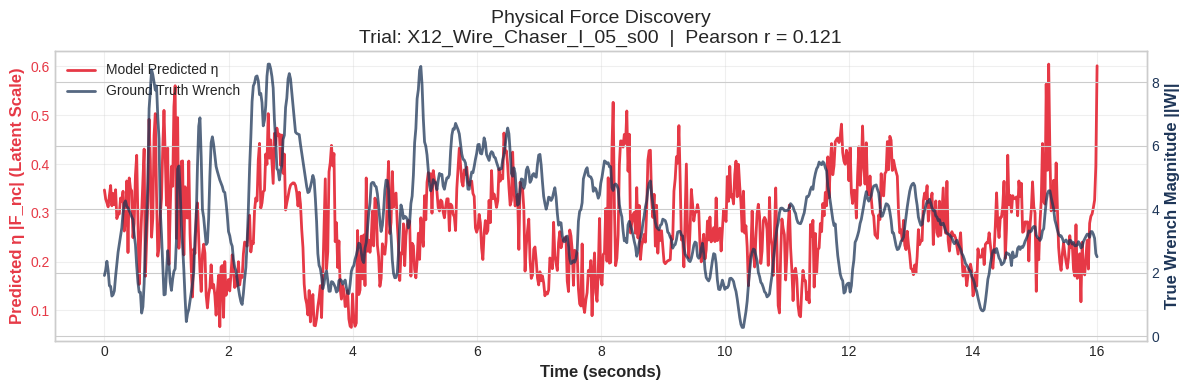

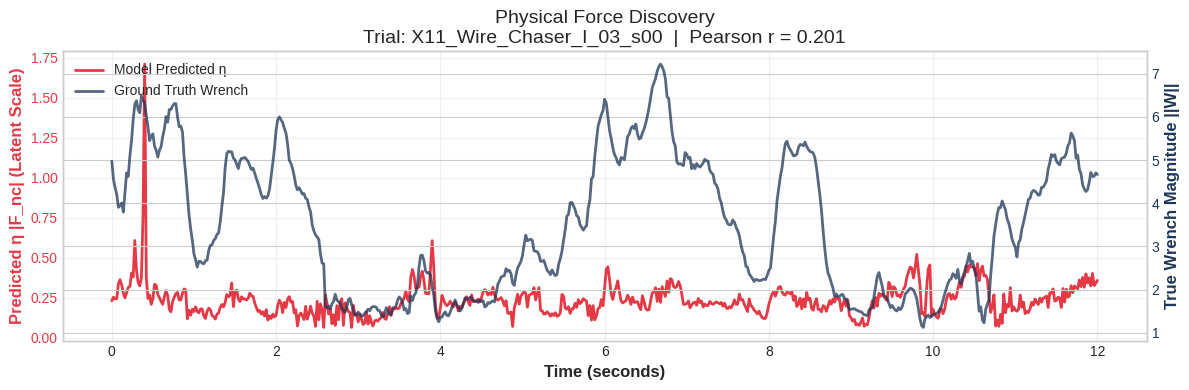

In [22]:
# --- Execution: Curating 9 Mixed Trials (Train, Test-ID, Test-OOD) ---

print("Curating segments for Force Discovery Overlays...")

def get_longest_segs(seg_list, split_name, n=3):
    """Safely extracts the top N longest segments from a given split."""
    if not seg_list:
        return []
    # Sort descending by length so we get the most interaction-heavy windows
    sorted_list = sorted(seg_list, key=lambda x: x['length'], reverse=True)
    selected = sorted_list[:n]
    print(f"Selected {len(selected)} from {split_name} Split.")
    return selected

viz_trials = []
viz_trials.extend(get_longest_segs(train_segs, "Train (LOUO)", 5))
viz_trials.extend(get_longest_segs(test_segs, "Test (In-Distribution)", 5))
viz_trials.extend(get_longest_segs(ood_segs, "Test (Out-of-Distribution)", 5))

print(f"\nGenerating {len(viz_trials)} mixed Force Discovery plots...")

plot_force_discovery(
    model=dnn,
    params_ensemble=final_params,
    trials_to_plot=viz_trials,
    state_mean=state_mean,
    state_std=state_std,
    fps=DVRK_FPS
)